# Critical-Phase Shadow Reservoirs (CPSR) on IBM Quantum

This notebook implements CPSR on **IBM Qiskit** so that every circuit runs on **IBM quantum computers** (IBM Heron devices). Broadly, it utilises the following functions:

1. A tunable-coupling quantum circuit at intermediate coupling produces a rich nonlinear **feature map**.
2. **Classical shadows** are extracted via randomized Pauli measurements.
3. A purely **classical learner** (MLP / Ridge) is trained on those shadow features.
4. At **feature-acquisition time** a quantum device is used once; the trained classical model is then reused for repeated readout.

## Section 0: Install dependencies

In [ ]:
%pip install "qiskit>=1.2" qiskit-aer qiskit-ibm-runtime scikit-learn numpy matplotlib networkx

## Section 1: Imports

All external dependencies in one place; internal helpers (topologies, shadow extractor, LUQPI pipeline) are defined directly in the cells below. Set `USE_REAL_HARDWARE`/`IBM_BACKEND_NAME` in Section 2 to target a real QPU.

In [2]:
%matplotlib inline
from __future__ import annotations
import os, time, pickle, warnings
from dataclasses import dataclass, field
from typing import List, Tuple, Optional
warnings.filterwarnings('ignore', category=UserWarning)

# Numerical / plotting
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import networkx as nx

# scikit-learn (classical learners)
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import PolynomialFeatures

# Qiskit + IBM Heron device / noisy simulator
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2
from qiskit_ibm_runtime.fake_provider import FakeTorino

print('Environment ready: Qiskit', qiskit.__version__)

Environment ready: Qiskit 2.5.2


## Section 2: Hardware foundation — IBM Heron device + reservoir topologies

Builds the reservoir connectivity motifs (Disconnected, Zigzag, StarHub, Chain, Ladder) on a real **IBM Heron** coupling graph (`FakeTorino`: 133 qubits, heavy-hex). Because heavy-hex has no small cycles, the entangling motifs are built as native, SWAP-free connected patches spanning a controlled range of scrambling power: a plain chain (`Zigzag`), a chain routed through one degree-3 branch vertex (`Chain`), and two degree-3 hubs bridged natively (`Ladder`). The closed-loop **hex-ring plaquette** (12-cycle) is used for the device overlay.

**Reproducibility / security (comments 9, 13).** `USE_REAL_HARDWARE` defaults to **False** (calibrated noisy `FakeTorino`). For any *reported* hardware run you must **pin a device by name** (`IBM_BACKEND_NAME`) — `least_busy` does not guarantee a processor family or basis-gate set and can change between runs. The required native gate set is asserted from `backend.target`, and backend name / version / calibration time are captured via `backend_metadata()`. No credentials are stored in the notebook.

> **Naming caveat.** `Chain`, `Zigzag`, `Ladder`, `StarHub` name graph/**connectivity** motifs on the heavy-hex lattice; they are **not** topological phases in the condensed-matter sense.


In [3]:
# SECURITY FIX (review comment 13): no hard-coded credentials in the notebook.
# ---------------------------------------------------------------------------
# The previously committed IBM API token has been REMOVED. If you are the
# author of the original notebook, treat that token as compromised and
# ROTATE/REVOKE it in the IBM Quantum dashboard, and purge it from git history
# (e.g. `git filter-repo`) before sharing this file.
#
# Authentication is now loaded from the Qiskit account store or an environment
# variable, and is only touched when USE_REAL_HARDWARE is True (Section 2).
# By default USE_REAL_HARDWARE=False and everything runs on the calibrated
# noisy FakeTorino simulator, so this cell is a no-op in the default config.

import os

def save_ibm_account_from_env(overwrite: bool = True) -> bool:
    """Persist an IBM Quantum account ONLY if a token is supplied via env vars.

    Set these in your shell (never in the notebook), e.g.:
        export IBM_QUANTUM_TOKEN=...        # your API token
        export IBM_QUANTUM_INSTANCE=crn:... # optional CRN/instance
    Returns True if an account was saved, False if no token was found.
    """
    token = os.environ.get("IBM_QUANTUM_TOKEN")
    if not token:
        print("No IBM_QUANTUM_TOKEN in environment — staying on the noisy "
              "FakeTorino simulator (USE_REAL_HARDWARE=False).")
        return False
    from qiskit_ibm_runtime import QiskitRuntimeService
    QiskitRuntimeService.save_account(
        channel="ibm_quantum_platform",
        token=token,
        instance=os.environ.get("IBM_QUANTUM_INSTANCE"),  # optional
        overwrite=overwrite,
    )
    print("IBM Quantum account saved from environment variables.")
    return True

# Only attempt to save an account when the user has explicitly opted into
# real hardware AND provided a token via the environment.
if os.environ.get("IBM_QUANTUM_TOKEN"):
    save_ibm_account_from_env()


In [4]:
# SECTION 2: Hardware foundation — IBM Heron device + reservoir topologies
# ============================================================================
# Review fixes in this cell:
#   * Comment 9  — backend selection is PINNED (a device name is required for
#                  any reported real-hardware run) and its native gate set is
#                  asserted; backend metadata (name, version, calibration time)
#                  is captured for provenance.
#   * Comment 13 — USE_REAL_HARDWARE defaults to False (noisy FakeTorino);
#                  no credentials live in the notebook.
# ----------------------------------------------------------------------------
USE_REAL_HARDWARE = False           # default: calibrated noisy FakeTorino sim
# For any REPORTED hardware experiment you MUST pin a device by name so the
# processor family / basis-gate set / calibration are reproducible. least_busy
# does NOT guarantee a device family and can change between runs (comment 9).
IBM_BACKEND_NAME  = "ibm_torino"    # e.g. an IBM Heron r1 device; set to yours
ALLOW_LEAST_BUSY  = False           # opt-in escape hatch; makes runs device-agnostic
REQUIRED_NATIVE_2Q = "cz"           # IBM Heron native entangler
_CACHE = {}

def get_ibm_backend():
    """Return the IBM backend (a PINNED real Heron device or the FakeTorino
    snapshot). For real hardware a concrete IBM_BACKEND_NAME is required unless
    ALLOW_LEAST_BUSY is explicitly set (comment 9)."""
    if 'backend' not in _CACHE:
        if USE_REAL_HARDWARE:
            from qiskit_ibm_runtime import QiskitRuntimeService
            service = QiskitRuntimeService()
            if IBM_BACKEND_NAME:
                be = service.backend(IBM_BACKEND_NAME)
            elif ALLOW_LEAST_BUSY:
                warnings.warn("Using least_busy(): the selected device family can "
                              "change between runs. Results are device-agnostic and "
                              "backend metadata must be stored with every result.")
                be = service.least_busy(operational=True, simulator=False, min_num_qubits=27)
            else:
                raise RuntimeError(
                    "USE_REAL_HARDWARE=True but IBM_BACKEND_NAME is None. Pin a device "
                    "name for reproducibility, or set ALLOW_LEAST_BUSY=True to opt into "
                    "device-agnostic runs (comment 9).")
        else:
            be = FakeTorino()
        _CACHE['backend'] = be
        _assert_native_gateset(be)
    return _CACHE['backend']

def _assert_native_gateset(be) -> None:
    """Assert the required native operations exist in backend.target (comment 9)."""
    try:
        ops = set(be.target.operation_names)
    except Exception:
        try:
            ops = set(be.configuration().basis_gates)
        except Exception:
            ops = set()
    if ops and REQUIRED_NATIVE_2Q not in ops:
        raise RuntimeError(
            f"Backend {getattr(be,'name','?')} does not expose native "
            f"'{REQUIRED_NATIVE_2Q}'. Native ops = {sorted(ops)}. The CPSR "
            f"topology / CP(2g) decomposition assumes a native-CZ heavy-hex device.")

def backend_metadata(be=None) -> dict:
    """Provenance record stored with every hardware result (comments 9, 10, recs)."""
    be = be or get_ibm_backend()
    md = {'name': getattr(be, 'name', str(be)), 'num_qubits': be.num_qubits}
    try:    md['basis_gates'] = sorted(be.target.operation_names)
    except Exception: md['basis_gates'] = None
    for attr in ('version', 'backend_version'):
        try:    md[attr] = getattr(be, attr)
        except Exception: pass
    try:    md['processor_type'] = be.processor_type
    except Exception: pass
    try:
        props = be.properties()
        md['calibration_time'] = str(getattr(props, 'last_update_date', None))
    except Exception:
        md['calibration_time'] = None
    return md

def ibm_qubits() -> List[int]:
    """All physical qubit indices on the device, sorted."""
    return sorted(range(get_ibm_backend().num_qubits))

def ibm_couplers() -> List[Tuple[int, int]]:
    """All native CZ couplers (undirected) on the device."""
    if 'couplers' not in _CACHE:
        be = get_ibm_backend()
        edges = be.coupling_map.get_edges()
        _CACHE['couplers'] = sorted(set(tuple(sorted(e)) for e in edges))
    return _CACHE['couplers']

def _graph() -> nx.Graph:
    if 'graph' not in _CACHE:
        G = nx.Graph(); G.add_edges_from(ibm_couplers())
        _CACHE['graph'] = G
    return _CACHE['graph']

def _readout_err(q: int) -> float:
    be = get_ibm_backend()
    try:
        return float(be.target['measure'][(q,)].error)
    except Exception:
        return 0.0

# ----------------------------------------------------------------------------
# Topology base + concrete topologies
# NOTE (rec: topology labels): 'Chain', 'Zigzag', 'Ladder', 'StarHub' name
# graph/CONNECTIVITY motifs on the heavy-hex lattice. They are NOT topological
# phases in the condensed-matter sense (no Hamiltonian symmetry/invariant or
# phase diagnostic is implemented here).
# ----------------------------------------------------------------------------
@dataclass
class Topology:
    """A reservoir topology = list of physical qubits + list of CZ edges + label."""
    name: str
    qubits: List[int]
    edges: List[Tuple[int, int]]
    triangles: List[Tuple[int, ...]] = field(default_factory=list)  # plaquette motifs
    swap_overhead: int = 0

    @property
    def N(self) -> int:
        return len(self.qubits)

    def check_native(self, backend=None) -> bool:
        native = set(map(frozenset, ibm_couplers()))
        return all(frozenset(e) in native for e in self.edges)

def _induced_edges(nodes) -> List[Tuple[int, int]]:
    s = set(nodes)
    return [(a, b) for (a, b) in ibm_couplers() if a in s and b in s]

def _pick_path(N: int) -> List[int]:
    """Pick a low-readout-error simple path of N qubits (max degree 2 -> a chain)."""
    G = _graph()
    low = [q for q in G.nodes() if G.degree(q) <= 2]
    start = min(low, key=_readout_err) if low else min(G.nodes(), key=_readout_err)
    best = [start]
    def dfs(path, deg_cap):
        nonlocal best
        if len(path) > len(best): best = list(path)
        if len(best) >= N: return True
        for nb in sorted(G[path[-1]], key=_readout_err):
            if nb not in path and G.degree(nb) <= deg_cap:
                path.append(nb)
                if dfs(path, deg_cap): return True
                path.pop()
        return False
    dfs([start], 2)
    if len(best) < N:                       # relax degree cap if grid forces it
        best = [start]; dfs([start], 3)
    return best[:N]

def _deg3_nodes() -> List[int]:
    G = _graph()
    return [q for q in G.nodes() if G.degree(q) == 3]

def _pick_single_hub(N: int) -> List[int]:
    """Path routed through one degree-3 branch vertex (a 'caterpillar' with 1 hub)."""
    G = _graph()
    hubs = _deg3_nodes()
    if not hubs:
        return _pick_path(N)
    center = min(hubs, key=_readout_err)
    chosen = [center]
    for nb in sorted(G[center], key=_readout_err):
        if len(chosen) < N: chosen.append(nb)
    while len(chosen) < N:
        frontier = [n for c in chosen for n in G[c] if n not in chosen]
        if not frontier: break
        cand = max(frontier, key=lambda x: (G.degree(x),
                   len([n for n in G[x] if n in chosen]), -_readout_err(x)))
        chosen.append(cand)
    return chosen[:N]

def _pick_double_hub(N: int) -> List[int]:
    """Two degree-3 hubs bridged through a degree-2 qubit (heavy-hex 'ladder' motif)."""
    G = _graph()
    hubs = _deg3_nodes()
    best = None
    for i, h1 in enumerate(hubs):
        for h2 in hubs[i + 1:]:
            try:
                if nx.shortest_path_length(G, h1, h2) == 2:
                    err = _readout_err(h1) + _readout_err(h2)
                    if best is None or err < best[0]:
                        best = (err, h1, h2)
            except nx.NetworkXNoPath:
                continue
    if best is None:
        return _pick_single_hub(N)
    _, h1, h2 = best
    bridge = [n for n in G[h1] if n in G[h2]][0]
    chosen = [h1, bridge, h2]
    for nb in G[h1]:
        if nb not in chosen and len(chosen) < N: chosen.append(nb)
    for nb in G[h2]:
        if nb not in chosen and len(chosen) < N: chosen.append(nb)
    while len(chosen) < N:
        frontier = [n for c in chosen for n in G[c] if n not in chosen]
        if not frontier: break
        chosen.append(min(frontier, key=_readout_err))
    return chosen[:N]

def _hex_ring(min_len: int = 12):
    """Return a heavy-hex hexagonal ring (closed 12-cycle) with lowest total readout
    error — the native IBM analog of Willow's 4-cycle plaquette (a closed loop for
    correlation spreading). Used for the device-overlay figure / large-N motif."""
    G = _graph()
    rings = [c for c in nx.cycle_basis(G) if len(c) >= min_len]
    if not rings:
        return None
    ring = min(rings, key=lambda c: sum(_readout_err(q) for q in c))
    H = G.subgraph(ring)
    try:
        cyc = nx.find_cycle(H)
        ordered = [cyc[0][0]] + [b for a, b in cyc]
        return ordered[:len(ring)]
    except Exception:
        return list(ring)

def topology_product_state(N: int) -> Topology:
    """No entanglement. Baseline: pure product-state evolution."""
    qs = _pick_path(N)
    return Topology(name=f"Disconnected(N={N})", qubits=qs, edges=[])

def topology_brick_wall(N: int) -> Topology:
    """Zigzag: a nearest-neighbor chain (all vertices degree <= 2)."""
    qs = _pick_path(N)
    return Topology(name=f"Zigzag(N={N})", qubits=qs, edges=_induced_edges(qs))

def topology_star_hub(N: int) -> Topology:
    """Star hub: one central qubit connected to all others (needs SWAPs on heavy-hex)."""
    qs = _pick_single_hub(N)
    hub = qs[0]
    edges = [(hub, qs[i]) for i in range(1, N)]
    couplers = set(map(frozenset, ibm_couplers()))
    swap = sum(1 for e in edges if frozenset(e) not in couplers)
    return Topology(name=f"StarHub(N={N})", qubits=qs, edges=edges, swap_overhead=swap)

def topology_muta_chain(N: int) -> Topology:
    """Chain: a native path routed through ONE degree-3 hub (single-hub caterpillar)."""
    qs = _pick_single_hub(N)
    return Topology(name=f"Chain(N={N})", qubits=qs, edges=_induced_edges(qs),
                    triangles=[])

def topology_muta_ladder(N: int) -> Topology:
    """Ladder: TWO degree-3 hubs bridged natively (densest heavy-hex scrambler)."""
    qs = _pick_double_hub(N)
    return Topology(name=f"Ladder(N={N})", qubits=qs, edges=_induced_edges(qs),
                    triangles=[])

def topology_hex_ring(N: int = 12) -> Topology:
    """Hexagonal-ring plaquette (closed 12-cycle) — the native heavy-hex analog of
    Willow's 4-cycle plaquette. Used for the device overlay and large-N motif."""
    ring = _hex_ring(12)
    if ring is None:
        return topology_muta_ladder(N)
    qs = ring[:N] if N <= len(ring) else ring
    edges = _induced_edges(qs)
    return Topology(name=f"HexRing(N={len(qs)})", qubits=qs, edges=edges,
                    triangles=[tuple(qs)])

TOPOLOGY_BUILDERS = {
    'Disconnected': topology_product_state,
    'Zigzag':       topology_brick_wall,
    'StarHub':      topology_star_hub,
    'Chain':        topology_muta_chain,
    'Ladder':       topology_muta_ladder,
}

# ----------------------------------------------------------------------------
# Native-CZ unitary helpers  (Qiskit build -> big-endian numpy unitary)
# ----------------------------------------------------------------------------
def _pack_moments(edges):
    """Greedy edge-coloring into parallel CZ moments (no shared qubit per moment)."""
    used, moments, cur = set(), [], []
    for e in edges:
        if e[0] in used or e[1] in used:
            moments.append(cur); cur = [e]; used = {e[0], e[1]}
        else:
            cur.append(e); used.update(e)
    if cur: moments.append(cur)
    return moments

def _local_index(topo: Topology):
    return {q: i for i, q in enumerate(topo.qubits)}

def circuit_to_unitary(qc: QuantumCircuit) -> np.ndarray:
    """Big-endian unitary (qubit 0 = most-significant) matching Cirq/numpy convention."""
    return Operator(qc.reverse_bits()).data

# ----------------------------------------------------------------------------
# Legacy QELM/QRC layer (kept for completeness; not on the reported CPSR path)
# ----------------------------------------------------------------------------
def build_qrc_layer(topo: Topology, u_t: float, bias_z, bias_x, n_input_qubits: int = 1) -> QuantumCircuit:
    """One QRC layer as a Qiskit circuit on N local qubits (state-vector, no reset)."""
    N = topo.N; idx = _local_index(topo)
    qc = QuantumCircuit(N)
    for i in range(n_input_qubits):
        qc.ry(np.pi * u_t, i)
    for layer in _pack_moments(topo.edges):
        for (a, b) in layer:
            qc.cz(idx[a], idx[b])
    for i in range(N): qc.rz(bias_z[i], i)
    for i in range(N): qc.rx(bias_x[i], i)
    return qc

def _depolarize_qubit(rho, qubit, N, p):
    if p <= 0: return rho
    dim = 2 ** N; sh = (2,) * (2 * N); rho_t = rho.reshape(sh)
    rho_x = rho_t.copy()
    rho_x = np.swapaxes(rho_x, qubit, 0)[::-1]; rho_x = np.swapaxes(rho_x, 0, qubit)
    rho_x = np.swapaxes(rho_x, N + qubit, N)[:, ::-1]; rho_x = np.swapaxes(rho_x, N, N + qubit)
    z_mask = np.array([1, -1], dtype=np.complex128); sh_r = [1] * N; sh_r[qubit] = 2
    zf = z_mask.reshape(sh_r)
    z_full = zf.reshape(sh_r + [1] * N) * zf.reshape([1] * N + sh_r)
    rho_z = rho_t * z_full
    rho_y = (rho_t * z_full).copy()
    rho_y = np.swapaxes(rho_y, qubit, 0)[::-1]; rho_y = np.swapaxes(rho_y, 0, qubit)
    rho_y = np.swapaxes(rho_y, N + qubit, N)[:, ::-1]; rho_y = np.swapaxes(rho_y, N, N + qubit)
    return (1.0 - p) * rho + (p / 3.0) * (rho_x.reshape(dim, dim)
            + rho_y.reshape(dim, dim) + rho_z.reshape(dim, dim))

def _bit_table(dim, N):
    bits = np.zeros((dim, N), dtype=np.int8)
    for b in range(dim):
        for i in range(N): bits[b, i] = (b >> (N - 1 - i)) & 1
    return bits

def kernel_quality(states_list):
    mat = np.stack(states_list, axis=1); s = np.linalg.svd(mat, compute_uv=False)
    return int(np.sum(s > 1e-6 * s[0]))

# ============================================================================


## Section 3: Benchmark tasks (k-Pauli, Parity, Volterra, Quantum-Phase)

Four temporal benchmarks: k-Body Pauli Product (multi-body correlation), Temporal Parity (XOR), Sparse Volterra Kernel (polynomial), and Quantum Phase Recognition. CPSR is primarily evaluated on **k-Pauli**, where shadow features provide a sample-efficiency head-start.

In [5]:
# SECTION 3: Benchmark tasks
# ============================================================================
def random_input(T, seed=0):
    return np.random.RandomState(seed).uniform(0.0, 1.0, size=T)

def task_kbody_pauli(T, k, seed=0):
    u = random_input(T, seed=seed); y = np.zeros(T)
    for t in range(k, T):
        p = 1.0
        for j in range(1, k + 1): p *= np.cos(np.pi * u[t - j])
        y[t] = p
    return u, y

def task_temporal_parity(T, k, seed=0):
    u = random_input(T, seed=seed); bits = (u > 0.5).astype(int); y = np.zeros(T)
    for t in range(k, T):
        x = 0
        for j in range(1, k + 1): x ^= bits[t - j]
        y[t] = 2 * x - 1
    return u, y

def task_sparse_volterra(T, k, seed=0):
    u = random_input(T, seed=seed); y = np.zeros(T)
    if k <= 5:
        for t in range(max(1, k), T): y[t] = u[t - 1] * u[t - k]
    else:
        for t in range(k, T): y[t] = u[t - 1] * u[t - 5] * u[t - k]
    return u, y

def task_quantum_phase(T, k, seed=0):
    rng = np.random.RandomState(seed); alpha_A = 0.3; n_seg = 10; seg = T // n_seg; u = np.zeros(T)
    for s in range(n_seg):
        lo = s * seg; hi = lo + seg if s < n_seg - 1 else T
        if s % 2 == 0:
            ua = np.zeros(hi - lo); ua[0] = rng.uniform(0, 1)
            for t in range(1, len(ua)): ua[t] = alpha_A * ua[t - 1] + (1 - alpha_A) * rng.uniform(0, 1)
            u[lo:hi] = ua
        else:
            ub = np.zeros(hi - lo); c = np.ones(k) / k * 0.85
            for t in range(len(ub)):
                ub[t] = (rng.uniform(0, 1) if t < k else
                         sum(c[j] * ub[t - 1 - j] for j in range(k)) + 0.15 * rng.uniform(0, 1))
            u[lo:hi] = np.clip(ub, 0, 1)
    W = 20; uc = u - np.mean(u); uv = np.var(u) + 1e-9; y = np.zeros(T)
    for t in range(T):
        lo = max(k, t - W + 1)
        if lo > t: continue
        acc = sum(uc[s] * uc[s - k] for s in range(lo, t + 1)); y[t] = acc / ((t - lo + 1) * uv)
    return u, y

TASKS = {'k-Body Pauli Product': task_kbody_pauli, 'Temporal Parity (k-XOR)': task_temporal_parity,
         'Sparse Volterra Kernel': task_sparse_volterra, 'Quantum Phase Recognition': task_quantum_phase}

# ============================================================================

## Section 4: CPSR core — tunable coupling, classical shadows, LUQPI

The three technical pieces of CPSR:

**1. Tunable-coupling layer** — each native CZ is replaced by $\mathrm{CZ}^{2g/\pi}=\mathrm{CP}(2g)$. At $g=0$ the circuit is a product map (no entanglement); at $g=\pi/2$ it is maximally entangling; intermediate $g$ spans a **high-scrambling regime** near the operator-entanglement maximum. Unitaries are built in Qiskit and read out big-endian (qubit-0 = MSB) via `Operator(qc.reverse_bits())`.

**2. Temporal architecture (two explicit framings, comment 1).**
- `mode='feature_map'` (default): a **window-encoded quantum feature map / QELM**. The state resets each step; the past `window_size` inputs are re-injected. Recall of $u(t-k)$ here measures nonlinear separability of a lagged-input feature map, *not* intrinsic reservoir memory.
- `mode='recurrent'`: **true recurrent dynamics** $|\psi_t\rangle=U(u_t)|\psi_{t-1}\rangle$; only the current input is injected and the state is carried forward. `memory_capacity_pcsr` uses this mode with a **washout**, so a nonzero $\mathrm{MC}_k$ reflects information the quantum system retained.

**3. Classical shadow extractor** — random-Pauli protocol: sample a random local Pauli basis per qubit, rotate, measure. For the exact reference we use the state-vector shortcut (`n_shots=0`). For finite shot budgets (`n_shots>0`) we use a **faithful shot-by-shot randomized-measurement estimator** (comment 4) — one random basis per shot, Born-sampled bit strings, and the same $3^w$ estimator used on hardware. Independent Gaussian feature noise (the previous shortcut) has been removed because it erases basis-coverage, heteroscedasticity, and feature correlations.

**Corrected physics (comments 5, 6).** The $\langle Y_iY_j\rangle$ correlator now carries the correct $i^2=-1$ sign, and the Y-basis pre-rotation is $H\cdot S^\dagger$ (Sdg then H). Both are checked analytically in the unit-test cell below on $|0\rangle,|+\rangle,|{+}i\rangle,|\Phi^+\rangle,|\Psi^-\rangle$.

**4. LUQPI pipeline** — a purely classical MLP/Ridge trained on shadow features, with **chronological, guard-gapped** train/validation/test splits (comment 8): overlapping windows can no longer leak future information into training.


In [6]:
# SECTION 4: PCSR core — critical phase, classical shadows, LUQPI
# ============================================================================
# Review fixes in this cell:
#   * Comment 1 — pcsr_reservoir now supports two EXPLICIT framings:
#       mode='feature_map' (default): window-encoded quantum feature map /
#           QELM — the state is reset each step and the past `window_size`
#           inputs are re-injected by the classical encoder. This is NOT a
#           memory-retaining reservoir; delayed information is supplied by the
#           preprocessing, so recall of u(t-k) reflects feature separability,
#           not intrinsic quantum memory.
#       mode='recurrent': genuine recurrent dynamics |psi_t> = U(u_t)|psi_{t-1}>.
#           Only the CURRENT input is injected; the state is carried across
#           steps. Memory capacity computed from this mode (with washout) is a
#           faithful measure of retained reservoir memory.
#   * Comment 5 — YY correlator sign corrected (Y^2 contributes i^2 = -1).
#   * Comment 6 — Y-basis pre-rotation corrected to H . S^dagger.
#   * Comment 4 — finite-shot shadows use a FAITHFUL shot-by-shot randomized
#     local-Pauli estimator (same estimator/basis protocol as the hardware
#     path), not independent Gaussian perturbations.
#   * Comment 8 — chronological train/val/test split with a guard gap.
#   * Comment 7 — adjacent-gap-ratio (r-statistic) chaos diagnostic added.
# ----------------------------------------------------------------------------
def critical_reservoir_unitary(topo, g, bias_z, bias_x, fixed_layer=True):
    """Big-endian unitary of ONE reservoir layer at coupling g.
       CZ^(2g/pi) == controlled-phase CP(2g): g=0 -> identity, g=pi/2 -> full CZ."""
    N = topo.N; idx = _local_index(topo); qc = QuantumCircuit(N)
    for layer in _pack_moments(topo.edges):
        for (a, b) in layer: qc.cp(2.0 * g, idx[a], idx[b])
    if fixed_layer:
        for i in range(N): qc.rz(bias_z[i], i)
        for i in range(N): qc.rx(bias_x[i], i)
    return circuit_to_unitary(qc)

def _encode_window_unitary(window, N, window_size):
    """RY feature encoder: spread the window across qubits/slots (feature-map mode)."""
    slot_phase = np.linspace(0.5, 1.0, window_size); slot_to_qubit = [w % N for w in range(window_size)]
    per = np.zeros(N)
    for w, u in enumerate(window): per[slot_to_qubit[w]] += np.pi * u * slot_phase[w]
    U = np.array([[1.0]], dtype=np.complex128)
    for i in range(N):
        c, s = np.cos(per[i] / 2), np.sin(per[i] / 2)
        U = np.kron(U, np.array([[c, -s], [s, c]], dtype=np.complex128))
    return U

def _encode_scalar_unitary(u_t, N, input_qubits):
    """RY injection of a SINGLE current input on the designated input qubit(s)
    (recurrent mode: only u_t enters each step)."""
    per = np.zeros(N)
    for q in input_qubits: per[q] += np.pi * u_t
    U = np.array([[1.0]], dtype=np.complex128)
    for i in range(N):
        c, s = np.cos(per[i] / 2), np.sin(per[i] / 2)
        U = np.kron(U, np.array([[c, -s], [s, c]], dtype=np.complex128))
    return U

def pcsr_reservoir(topo, u_sequence, g, bias_z=None, bias_x=None, seed=42, window_size=8,
                   reps=2, mode='feature_map', input_qubits=(0,)):
    """Run the PCSR reservoir at coupling g. Returns state vectors (T, 2**N).

    mode='feature_map' (default, comment 1): reset-and-window QUANTUM FEATURE MAP
        (QELM-like). psi is reset to |0> each step and the last `window_size`
        inputs are re-injected. Delayed inputs are present because the classical
        encoder supplies them — this is a lagged-input quantum feature map, not a
        memory-retaining reservoir.
    mode='recurrent' (comment 1): TRUE recurrent dynamics. psi is carried from
        t-1 to t and only the current input u_t is injected. Use this mode for any
        genuine reservoir-memory claim (memory_capacity_pcsr applies a washout).
    """
    rng = np.random.RandomState(seed); N = topo.N
    if bias_z is None: bias_z = rng.uniform(0, 2 * np.pi, size=N)
    if bias_x is None: bias_x = rng.uniform(0.3, 0.7, size=N)
    T = len(u_sequence); dim = 2 ** N
    U_step = np.linalg.matrix_power(critical_reservoir_unitary(topo, g, bias_z, bias_x), reps)
    states = np.zeros((T, dim), dtype=np.complex128)
    if mode == 'feature_map':
        psi0 = np.zeros(dim, dtype=np.complex128); psi0[0] = 1.0
        for t in range(T):
            lo = max(0, t - window_size + 1); wlen = t - lo + 1
            window = np.zeros(window_size); window[-wlen:] = u_sequence[lo:t + 1]
            states[t] = (U_step @ _encode_window_unitary(window, N, window_size)) @ psi0
    elif mode == 'recurrent':
        psi = np.zeros(dim, dtype=np.complex128); psi[0] = 1.0
        input_qubits = tuple(input_qubits)
        for t in range(T):
            psi = (U_step @ _encode_scalar_unitary(u_sequence[t], N, input_qubits)) @ psi
            psi = psi / (np.linalg.norm(psi) + 1e-15)   # guard numerical drift
            states[t] = psi
    else:
        raise ValueError(f"unknown mode {mode!r}; use 'feature_map' or 'recurrent'")
    return states

# ---- entanglement / chaos diagnostics --------------------------------------
def half_system_entropy(state, N):
    half = N // 2; psi = state.reshape(2 ** half, 2 ** (N - half))
    s = np.linalg.svd(psi, compute_uv=False); p = s ** 2; p = p[p > 1e-12]
    return float(-np.sum(p * np.log(p)))

def operator_entanglement(U, N):
    dh = 2 ** (N // 2)
    Um = U.reshape(dh, dh, dh, dh).transpose(0, 2, 1, 3).reshape(dh * dh, dh * dh)
    s = np.linalg.svd(Um, compute_uv=False); p = (s ** 2) / np.sum(s ** 2); p = p[p > 1e-12]
    return float(-np.sum(p * np.log(p)))

def spectral_form_factor(U):
    d = U.shape[0]; return float(np.abs(np.trace(U)) ** 2 / d)

def level_spacing_ratio(U):
    """Adjacent-gap ratio <r> of the Floquet quasi-energy spectrum (comment 7).

    Independent chaos diagnostic: <r> ~ 0.39 (Poisson, integrable/localized) vs
    ~ 0.60 (COE, quantum-chaotic). Computed from the eigenphases of the one-step
    unitary U, unfolded on the circle."""
    ev = np.linalg.eigvals(U); phases = np.sort(np.angle(ev))
    d = len(phases)
    gaps = np.diff(np.concatenate([phases, [phases[0] + 2 * np.pi]]))
    gaps = gaps[gaps > 1e-12]
    if len(gaps) < 3: return float('nan')
    r = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
    return float(np.mean(r))

# ---- exact Pauli expectations (reference / ideal-shadow shortcut) -----------
def exact_pauli_expectations(state, N, max_weight=2):
    """Exact 1- and matched-2-body Pauli expectations. Order per site: Z,X,Y;
    then pairs i<j: ZZ,XX,YY (kept identical to the shadow reconstruction order)."""
    dim = 2 ** N; bits = _bit_table(dim, N); probs = np.abs(state) ** 2; idx_all = np.arange(dim)
    labels, vals = [], []
    for i in range(N):
        z = 1 - 2 * bits[:, i]; labels.append(f'Z{i}'); vals.append(float(np.sum(probs * z)))
        flip = 1 << (N - 1 - i); idxf = idx_all ^ flip
        labels.append(f'X{i}'); vals.append(float(np.real(np.sum(np.conj(state) * state[idxf]))))
        labels.append(f'Y{i}'); vals.append(float(np.imag(np.sum(np.conj(state) * state[idxf] * z))))
    if max_weight >= 2:
        for i in range(N):
            for j in range(i + 1, N):
                zz = (1 - 2 * bits[:, i]) * (1 - 2 * bits[:, j])
                labels.append(f'Z{i}Z{j}'); vals.append(float(np.sum(probs * zz)))
                fi = 1 << (N - 1 - i); fj = 1 << (N - 1 - j); idx2 = idx_all ^ fi ^ fj
                labels.append(f'X{i}X{j}'); vals.append(float(np.real(np.sum(np.conj(state) * state[idx2]))))
                zi = 1 - 2 * bits[:, i]; zj = 1 - 2 * bits[:, j]
                labels.append(f'Y{i}Y{j}')
                # FIX (comment 5): two Y operators contribute a phase i^2 = -1, so
                # the YY double-flip term carries an overall MINUS sign.
                vals.append(float(-np.real(np.sum(zi * zj * np.conj(state) * state[idx2]))))
    return labels, np.array(vals)

# ---- classical-shadow feature extractors -----------------------------------
# Corrected single-qubit basis-change matrices (row-vector on |psi>, rightmost
# matrix acts first). For the Y basis the hardware runs Sdg then H, i.e. the
# state transform is H . S^dagger (comment 6).
_H2   = np.array([[1, 1], [1, -1]], dtype=np.complex128) / np.sqrt(2)
_SDG2 = np.array([[1, 0], [0, -1j]], dtype=np.complex128)
_HSdg = _H2 @ _SDG2                       # correct Y-basis pre-rotation
_I2   = np.eye(2, dtype=np.complex128)
_BASIS_ROT = {0: _I2, 1: _H2, 2: _HSdg}   # 0=Z, 1=X, 2=Y

def _labels_for(N, max_weight=2):
    labs, _ = exact_pauli_expectations(np.eye(2 ** N)[0], N, max_weight=max_weight)
    return labs

def randomized_shadow_estimates(state, N, n_shots, rng, max_weight=2):
    """FAITHFUL random-Pauli classical-shadow estimator (comment 4).

    Draws one random local-Pauli basis PER SHOT (textbook local shadows),
    samples a bit string from the Born distribution of the rotated state, and
    reconstructs every 1-body and matched-2-body Pauli from the SAME shot
    records using the 3^w single-shot estimator — identical in form to the
    hardware estimator `reconstruct_shadow_pauli`. Returns values aligned to
    `exact_pauli_expectations` label order. Observables with no compatible
    basis in the shot record return 0 (their genuine basis-coverage limitation).
    """
    dim = 2 ** N; bits = _bit_table(dim, N); signs = (1 - 2 * bits).astype(float)  # (dim,N)
    # accumulators (numerators only; the 3^w single-shot estimator is normalized
    # by the TOTAL shot count — matching the hardware estimator convention)
    num1 = np.zeros((3, N)); num2 = np.zeros((3, N, N))
    # group shots by identical basis for efficient Born sampling
    all_bases = rng.randint(0, 3, size=(n_shots, N))
    order = np.lexsort(all_bases.T)
    sb = all_bases[order]
    starts = np.concatenate([[0], 1 + np.where(np.any(sb[1:] != sb[:-1], axis=1))[0], [n_shots]])
    for a, b in zip(starts[:-1], starts[1:]):
        basis = sb[a]; n_b = b - a
        U = np.array([[1.0]], dtype=np.complex128)
        for i in range(N): U = np.kron(U, _BASIS_ROT[basis[i]])
        probs = np.abs(U @ state) ** 2; probs = probs / probs.sum()
        counts = rng.multinomial(n_b, probs)                     # (dim,)
        S1 = counts @ signs                                      # (N,) sum counts*sign_i
        wsig = counts[:, None] * signs                           # (dim,N)
        S2 = signs.T @ wsig                                      # (N,N) sum counts*sign_i*sign_j
        for i in range(N):
            num1[basis[i], i] += S1[i]
        for i in range(N):
            for j in range(i + 1, N):
                if basis[i] == basis[j]:
                    num2[basis[i], i, j] += S2[i, j]
    est1 = 3.0 * num1 / n_shots
    est2 = 9.0 * num2 / n_shots
    out = []
    for i in range(N):
        out += [est1[0, i], est1[1, i], est1[2, i]]             # Z,X,Y  order
    if max_weight >= 2:
        for i in range(N):
            for j in range(i + 1, N):
                out += [est2[0, i, j], est2[1, i, j], est2[2, i, j]]  # ZZ,XX,YY
    return np.array(out)

def basis_coverage_report(N, n_bases):
    """Prob. that a specific matched-2-body Pauli has >=1 compatible basis among
    n_bases independent random local bases (comment 11 diagnostic)."""
    p_none = (1.0 - 1.0 / 9.0) ** n_bases
    return {'n_bases': int(n_bases), 'p_two_body_uncovered': float(p_none),
            'p_two_body_covered': float(1 - p_none)}

def shadow_features(states, N, n_shots=0, seed=42, max_weight=2, method='randomized'):
    """Shadow feature matrix X (T, n_features).
       n_shots==0 -> exact Pauli expectations (ideal-shadow shortcut).
       n_shots>0  -> FAITHFUL randomized-measurement estimator (comment 4)."""
    rng = np.random.RandomState(seed); T = states.shape[0]
    labels0 = _labels_for(N, max_weight=max_weight)
    X = np.zeros((T, len(labels0)))
    for t in range(T):
        if n_shots > 0:
            X[t] = randomized_shadow_estimates(states[t], N, n_shots, rng, max_weight=max_weight)
        else:
            _, X[t] = exact_pauli_expectations(states[t], N, max_weight=max_weight)
    return labels0, X

def randomized_measurement_features(state, N, n_shots, seed=42):
    """Reference shot-by-shot randomized-measurement estimator for ALL 1-body and
    (matched + mixed) 2-body Paulis. Y-basis rotation fixed to H . S^dagger
    (comment 6)."""
    rng = np.random.RandomState(seed); dim = 2 ** N
    BASIS = _BASIS_ROT
    pauli_set = []
    for i in range(N):
        for p in [1, 2, 0]: pauli_set.append([(i, p)])
    for i in range(N):
        for j in range(i + 1, N):
            for p1 in [1, 2, 0]:
                for p2 in [1, 2, 0]: pauli_set.append([(i, p1), (j, p2)])
    est = np.zeros(len(pauli_set)); cnt = np.zeros(len(pauli_set))
    for _ in range(n_shots):
        basis = rng.randint(0, 3, size=N); U = np.array([[1.0]], dtype=np.complex128)
        for i in range(N): U = np.kron(U, BASIS[basis[i]])
        probs = np.abs(U @ state) ** 2; probs /= probs.sum(); outcome = rng.choice(dim, p=probs)
        bits = np.array([(outcome >> (N - 1 - i)) & 1 for i in range(N)])
        for k, ops in enumerate(pauli_set):
            if all(basis[i] == p for (i, p) in ops):
                sign = 1
                for (i, _) in ops: sign *= (-1) ** bits[i]
                est[k] += (3 ** len(ops)) * sign; cnt[k] += 1
    return np.where(cnt > 0, est / np.maximum(cnt, 1), 0.0)

# ---- data splitting (comment 8): chronological, guard-gapped ---------------
def chrono_split(T, train_frac=0.6, washout=30, gap=8, val_frac=0.2):
    """Chronological train / validation / test split with a guard gap of at least
    the window length between blocks (comment 8). Hyperparameters are chosen on
    the validation block; the final test block stays untouched until analysis is
    frozen. Returns (tr_idx, val_idx, te_idx)."""
    idx = np.arange(washout, T); n = len(idx)
    n_tr = int(n * train_frac); n_val = int(n * val_frac)
    tr = idx[:n_tr]
    val = idx[n_tr + gap: n_tr + gap + n_val]
    te = idx[n_tr + n_val + 2 * gap:]
    return tr, val, te

def luqpi_train_and_eval(X_shadow, y, model_type='mlp', alpha=1e-3, hidden=(64, 32),
                         seed=42, train_frac=0.6, val_frac=0.2, washout=30, gap=8):
    tr, val, te = chrono_split(len(y), train_frac, washout, gap, val_frac)
    model = (MLPRegressor(hidden_layer_sizes=hidden, max_iter=500, random_state=seed, alpha=alpha)
             if model_type == 'mlp' else Ridge(alpha=alpha))
    model.fit(X_shadow[tr], y[tr]); pred = model.predict(X_shadow[te]); yte = y[te]
    nrmse = float(np.sqrt(np.mean((pred - yte) ** 2) / (np.var(yte) + 1e-12)))
    return nrmse, model, pred

def classical_only_baseline(u, y, lags=10, model_type='mlp', hidden=(64, 32), seed=42,
                            train_frac=0.6, val_frac=0.2, washout=30, gap=8, alpha=1e-3):
    T = len(u); X = np.zeros((T, lags))
    for i in range(lags): X[i:, i] = u[:T - i]
    tr, val, te = chrono_split(T, train_frac, washout, gap, val_frac)
    model = (MLPRegressor(hidden_layer_sizes=hidden, max_iter=500, random_state=seed, alpha=alpha)
             if model_type == 'mlp' else Ridge(alpha=alpha))
    model.fit(X[tr], y[tr]); pred = model.predict(X[te])
    nrmse = float(np.sqrt(np.mean((pred - y[te]) ** 2) / (np.var(y[te]) + 1e-12)))
    return nrmse, model

# ============================================================================


### Physics unit tests

Analytic checks (comments 5, 6 and recommendation to add physics tests) run before any sweep.

In [7]:
# PHYSICS UNIT TESTS (review recommendation: add physics tests before sweeps)
# ============================================================================
# Analytic checks for the two definite bugs (YY sign, comment 5; Y-basis
# rotation, comment 6) plus 1-/2-qubit Pauli expectations and the faithful
# shadow estimator, on states with known answers: |0>, |+>, |+i>, |Phi+>, |Psi->.
# ----------------------------------------------------------------------------
def _ket(bitstr):
    N = len(bitstr); v = np.zeros(2 ** N, dtype=np.complex128); v[int(bitstr, 2)] = 1.0; return v

def _run_physics_unit_tests(verbose=True):
    tol = 1e-9; results = []
    def check(name, got, exp, atol=tol):
        ok = abs(got - exp) <= atol; results.append((name, got, exp, ok))
        if verbose: print(f"  [{'PASS' if ok else 'FAIL'}] {name}: got {got:+.4f}, expect {exp:+.4f}")

    # --- single-qubit expectations ---
    zero = _ket('0'); plus = np.array([1, 1], dtype=complex) / np.sqrt(2)
    plusi = np.array([1, 1j], dtype=complex) / np.sqrt(2)
    for lab, st, exp in [('<Z> on |0>', zero, 1.0), ('<X> on |0>', zero, 0.0),
                         ('<X> on |+>', plus, 1.0), ('<Z> on |+>', plus, 0.0),
                         ('<Y> on |+i>', plusi, 1.0), ('<Z> on |+i>', plusi, 0.0)]:
        labs, vals = exact_pauli_expectations(st, 1, max_weight=1)
        d = dict(zip(labs, vals)); key = lab[1]  # Z/X/Y
        check(lab, d[f'{key}0'], exp)

    # --- Bell |Phi+> : <XX>=+1, <ZZ>=+1, <YY>=-1 (comment 5) ---
    phip = (_ket('00') + _ket('11')) / np.sqrt(2)
    labs, vals = exact_pauli_expectations(phip, 2); d = dict(zip(labs, vals))
    check('<XX> on |Phi+>', d['X0X1'], +1.0)
    check('<ZZ> on |Phi+>', d['Z0Z1'], +1.0)
    check('<YY> on |Phi+>', d['Y0Y1'], -1.0)     # was +1 before the sign fix
    # --- singlet |Psi-> : <XX>=<YY>=<ZZ>=-1 ---
    psim = (_ket('01') - _ket('10')) / np.sqrt(2)
    labs, vals = exact_pauli_expectations(psim, 2); d = dict(zip(labs, vals))
    check('<XX> on |Psi->', d['X0X1'], -1.0)
    check('<YY> on |Psi->', d['Y0Y1'], -1.0)
    check('<ZZ> on |Psi->', d['Z0Z1'], -1.0)

    # --- Y-basis rotation (comment 6): H.S^dagger maps |+i>->0, |-i>->1 ---
    minusi = np.array([1, -1j], dtype=complex) / np.sqrt(2)
    p_plus = np.abs(_HSdg @ plusi) ** 2; p_minus = np.abs(_HSdg @ minusi) ** 2
    check('Y-rot |+i| -> P(0)', float(p_plus[0]), 1.0)
    check('Y-rot |-i| -> P(1)', float(p_minus[1]), 1.0)

    # --- faithful shadow estimator converges to exact (comment 4) ---
    rng = np.random.RandomState(0); st = rng.randn(8) + 1j * rng.randn(8); st /= np.linalg.norm(st)
    _, exv = exact_pauli_expectations(st, 3)
    shv = randomized_shadow_estimates(st, 3, 200000, np.random.RandomState(1))
    max_dev = float(np.max(np.abs(shv - exv)))
    ok = max_dev < 0.03; results.append(('shadow~exact (K=2e5)', max_dev, 0.0, ok))
    if verbose: print(f"  [{'PASS' if ok else 'FAIL'}] shadow~exact (K=2e5): max|dev|={max_dev:.4f} (<0.03)")

    n_fail = sum(1 for *_, ok in results if not ok)
    print(f"\nPhysics unit tests: {len(results)-n_fail}/{len(results)} passed.")
    assert n_fail == 0, f"{n_fail} physics unit test(s) FAILED"
    return results

_ = _run_physics_unit_tests()


  [PASS] <Z> on |0>: got +1.0000, expect +1.0000
  [PASS] <X> on |0>: got +0.0000, expect +0.0000
  [PASS] <X> on |+>: got +1.0000, expect +1.0000
  [PASS] <Z> on |+>: got +0.0000, expect +0.0000
  [PASS] <Y> on |+i>: got +1.0000, expect +1.0000
  [PASS] <Z> on |+i>: got +0.0000, expect +0.0000
  [PASS] <XX> on |Phi+>: got +1.0000, expect +1.0000
  [PASS] <ZZ> on |Phi+>: got +1.0000, expect +1.0000
  [PASS] <YY> on |Phi+>: got -1.0000, expect -1.0000
  [PASS] <XX> on |Psi->: got -1.0000, expect -1.0000
  [PASS] <YY> on |Psi->: got -1.0000, expect -1.0000
  [PASS] <ZZ> on |Psi->: got -1.0000, expect -1.0000
  [PASS] Y-rot |+i| -> P(0): got +1.0000, expect +1.0000
  [PASS] Y-rot |-i| -> P(1): got +1.0000, expect +1.0000


  [PASS] shadow~exact (K=2e5): max|dev|=0.0075 (<0.03)

Physics unit tests: 15/15 passed.


## Section 5: CPSR experiments — coupling scan, latency, robustness

- **Coupling scan** — sweep $g\in[0,\pi/2]$; measure half-system entropy, operator entanglement, an independent **adjacent-gap-ratio $\langle r\rangle$** chaos diagnostic (comment 7), **recurrent-mode** memory capacity (comment 1), and task NRMSE. Identifies the intermediate-coupling $g^\*$ where NRMSE is minimized, near the $S_{\rm op}$ maximum. This is reported as a **performance optimum / trade-off**, not a proven many-body phase transition at $N=6$.
- **LUQPI separation** — classical-only vs shadow-augmented across **realized** training-set sizes, with **chronological** splits.
- **Inference latency (honest, comment 2)** — separates (i) *classical readout after features are cached* from (ii) an *end-to-end* estimate that includes state preparation, randomized measurement, feature reconstruction and readout. Only (i) matches classical-only speed; a truly QPU-free deployment needs a learned surrogate.
- **Shadow shot robustness** — sweep the per-point shot budget $K$ using the **faithful randomized-measurement** estimator; each $K$ is $K$ independent random bases. Interpreted as *sensitivity* to the shot budget, not saturation of a physical shadow protocol.


In [8]:
# SECTION 5: PCSR experiments — phase scan, latency, robustness
# ============================================================================
# Review fixes in this cell:
#   * Comment 1  — memory capacity is measured from the RECURRENT reservoir
#     (state carried across steps, only u_t injected) with a washout, so recall
#     of u(t-k) reflects retained quantum memory rather than a lagged input the
#     encoder re-supplied. The feature-map framing keeps a separate,
#     correctly-labelled "feature memory" curve for comparison.
#   * Comment 2  — inference latency separates (i) classical readout AFTER
#     feature acquisition from (ii) an honest END-TO-END estimate that includes
#     state preparation, randomized measurement, reconstruction and readout.
#   * Comment 7  — phase scan also records the adjacent-gap-ratio <r>.
#   * Comment 8  — chronological, guard-gapped splits throughout.
#   * Comment 4  — shot robustness uses the faithful randomized-measurement shadows.
# ----------------------------------------------------------------------------
def memory_capacity_pcsr(topo, u, g, bias_z, bias_x, k_max=10, washout=30,
                         train_frac=0.6, val_frac=0.2, gap=8, mode='recurrent',
                         input_qubits=(0,)):
    """Linear memory capacity MC_k = corr^2(readout, u(t-k)).

    Computed from the RECURRENT reservoir by default (comment 1): the current
    input vector injected at step t contains only u_t, so a nonzero MC_k for
    k>=1 can only come from information the quantum state retained. A washout
    discards the first `washout` steps, and train/test are split chronologically.
    """
    T = len(u)
    states = pcsr_reservoir(topo, u, g, bias_z=bias_z, bias_x=bias_x,
                            mode=mode, input_qubits=input_qubits)
    _, X = shadow_features(states, topo.N, n_shots=0)
    tr, val, te = chrono_split(T, train_frac, washout, gap, val_frac)
    MCk = np.zeros(k_max)
    for k in range(1, k_max + 1):
        if k >= T - washout - 5: break
        target = np.zeros(T); target[k:] = u[:-k]
        m = Ridge(alpha=1e-6); m.fit(X[tr], target[tr])
        pred = m.predict(X[te]); true = target[te]
        denom = (np.var(true) * np.var(pred) + 1e-12)
        MCk[k - 1] = np.cov(pred, true)[0, 1] ** 2 / denom
    return MCk

def phase_scan(topology_name='Chain', N=6, T=300, g_values=None, k_for_task=3, seed=42):
    if g_values is None: g_values = np.linspace(0.0, np.pi / 2, 11)
    topo = TOPOLOGY_BUILDERS[topology_name](N)
    rng = np.random.RandomState(seed); bias_z = rng.uniform(0, 2 * np.pi, N); bias_x = rng.uniform(0.3, 0.7, N)
    out = {'g': g_values.tolist(), 'S_half': [], 'op_S': [], 'mc': [], 'r_stat': [],
           'nrmse_kpauli': [], 'nrmse_parity': []}
    u_kp, y_kp = task_kbody_pauli(T, k_for_task, seed=seed)
    u_par, y_par = task_temporal_parity(T, 3, seed=seed)
    u_rand = np.random.RandomState(seed + 1).uniform(0, 1, T)
    for g in g_values:
        # feature-map states drive the supervised tasks (QELM feature map)
        states_kp = pcsr_reservoir(topo, u_kp, g, bias_z=bias_z, bias_x=bias_x, mode='feature_map')
        states_par = pcsr_reservoir(topo, u_par, g, bias_z=bias_z, bias_x=bias_x, mode='feature_map')
        states_rand = pcsr_reservoir(topo, u_rand, g, bias_z=bias_z, bias_x=bias_x, mode='feature_map')
        S_half = np.mean([half_system_entropy(s, N) for s in states_rand[-30:]])
        U = critical_reservoir_unitary(topo, g, bias_z, bias_x)
        U2 = np.linalg.matrix_power(U, 2)
        op_S = operator_entanglement(U2, N)
        r_stat = level_spacing_ratio(U2)                       # comment 7 diagnostic
        _, X_kp = shadow_features(states_kp, N, n_shots=0)
        _, X_par = shadow_features(states_par, N, n_shots=0)
        nrmse_kp, _, _ = luqpi_train_and_eval(X_kp, y_kp, model_type='ridge', alpha=1e-4, seed=seed)
        nrmse_par, _, _ = luqpi_train_and_eval(X_par, y_par, model_type='mlp', hidden=(64, 32), seed=seed)
        # honest reservoir memory: recurrent dynamics with washout (comment 1)
        mc = float(np.sum(memory_capacity_pcsr(topo, u_rand, g, bias_z, bias_x,
                                                k_max=10, mode='recurrent')))
        out['S_half'].append(float(S_half)); out['op_S'].append(float(op_S)); out['mc'].append(mc)
        out['r_stat'].append(float(r_stat))
        out['nrmse_kpauli'].append(nrmse_kp); out['nrmse_parity'].append(nrmse_par)
        print(f'  g={g/np.pi:.3f}*pi  S_half={S_half:.3f}  op_S={op_S:.3f}  <r>={r_stat:.3f}  '
              f'MC(recurrent)={mc:.2f}  kPauli={nrmse_kp:.3f}  parity={nrmse_par:.3f}', flush=True)
    return out

def luqpi_separation_sweep(topology_name='Chain', N=6, T=400, g=np.pi / 4,
                           train_sizes=(50, 100, 150, 200, 240),
                           tasks_to_run=('kPauli', 'Parity', 'Volterra'), seed=42,
                           washout=30, gap=8, n_test=100):
    """Sample-efficiency sweep with CHRONOLOGICAL splits (comment 8) and REALIZED
    training-set sizes (comment 12). Training points are the first n_tr steps of
    the (post-washout) training block; the test block is the final n_test steps,
    separated by a guard gap. Realized sizes are stored, never the requested slice."""
    topo = TOPOLOGY_BUILDERS[topology_name](N)
    rng = np.random.RandomState(seed); bias_z = rng.uniform(0, 2 * np.pi, N); bias_x = rng.uniform(0.3, 0.7, N)
    task_fns = {'kPauli': (task_kbody_pauli, 3), 'Parity': (task_temporal_parity, 3),
                'Volterra': (task_sparse_volterra, 4), 'QPhase': (task_quantum_phase, 4)}
    te_idx = np.arange(T - n_test, T)
    train_pool = np.arange(washout, T - n_test - gap)          # guard gap before test
    out = {'requested_train_sizes': list(train_sizes), 'tasks': {}}
    for task_name in tasks_to_run:
        task_fn, k = task_fns[task_name]; u, y = task_fn(T, k, seed=seed)
        states = pcsr_reservoir(topo, u, g, bias_z=bias_z, bias_x=bias_x, mode='feature_map')
        _, X_shadow = shadow_features(states, N, n_shots=0)
        lags = 8; X_class = np.zeros((T, lags))
        for i in range(lags): X_class[i:, i] = u[:T - i]
        X_combined = np.concatenate([X_shadow, X_class], axis=1)
        nrmse_classical, nrmse_shadow, nrmse_combined, realized = [], [], [], []
        for n_tr in train_sizes:
            n_real = int(min(n_tr, len(train_pool)))           # realized size (comment 12)
            tr_idx = train_pool[:n_real]
            realized.append(n_real)
            def fit_eval(X, hidden=(64, 32), kind='mlp'):
                m = (MLPRegressor(hidden_layer_sizes=hidden, max_iter=400, random_state=seed, alpha=1e-3)
                     if kind == 'mlp' else Ridge(alpha=1e-3))
                m.fit(X[tr_idx], y[tr_idx]); pred = m.predict(X[te_idx])
                return float(np.sqrt(np.mean((pred - y[te_idx]) ** 2) / (np.var(y[te_idx]) + 1e-12)))
            nrmse_classical.append(fit_eval(X_class)); nrmse_shadow.append(fit_eval(X_shadow))
            nrmse_combined.append(fit_eval(X_combined))
        out['tasks'][task_name] = {'classical': nrmse_classical, 'shadow': nrmse_shadow,
                                   'combined': nrmse_combined, 'train_sizes': realized}
    return out

def inference_latency_benchmark(N=6, n_test_inputs=100, n_qpu_shots=300, n_bases=300, seed=42):
    """Latency per prediction, separated HONESTLY (comment 2):
       (a) classical_only     — classical MLP on lagged inputs.
       (b) readout_after_feat — classical readout AFTER quantum features already
           exist (the ONLY thing the old benchmark timed; renamed accordingly).
       (c) feature_acquisition_sim — compute cost of GENERATING one unseen input's
           shadow features (state prep + randomized measurement + reconstruction),
           on the state-vector simulator.
       (d) end_to_end_sim     — (b)+(c): true per-new-input cost in simulation.
       (e) qrc_sim            — standard QRC per-call (state-vector sim).
       (f) qrc_real_ibm_estimate       — standard QRC per-call on real IBM Heron.
       (g) pcsr_end_to_end_ibm_estimate — CPSR per NEW input on real IBM Heron:
           n_bases randomized-measurement circuits must be prepared+measured, so
           a genuinely QPU-free deployment needs a learned surrogate (see report).
    """
    topo = TOPOLOGY_BUILDERS['Chain'](N)
    rng = np.random.RandomState(seed); bias_z = rng.uniform(0, 2 * np.pi, N); bias_x = rng.uniform(0.3, 0.7, N)
    g = np.pi / 4
    u_train, y_train = task_kbody_pauli(300, 3, seed=seed)
    states_train = pcsr_reservoir(topo, u_train, g, bias_z=bias_z, bias_x=bias_x, mode='feature_map')
    _, X_train_shadow = shadow_features(states_train, N, n_shots=0)
    mlp_pcsr = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=400, random_state=seed); mlp_pcsr.fit(X_train_shadow[30:], y_train[30:])
    lags = 8; X_class_train = np.zeros((300, lags))
    for i in range(lags): X_class_train[i:, i] = u_train[:300 - i]
    mlp_classical = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=400, random_state=seed); mlp_classical.fit(X_class_train[30:], y_train[30:])
    u_test = rng.uniform(0, 1, 300)
    states_test = pcsr_reservoir(topo, u_test, g, bias_z=bias_z, bias_x=bias_x, mode='feature_map')
    _, X_test_shadow = shadow_features(states_test, N, n_shots=0)
    X_test_class = np.zeros((300, lags))
    for i in range(lags): X_test_class[i:, i] = u_test[:300 - i]
    # (a) classical only
    t0 = time.time()
    for _ in range(n_test_inputs): _ = mlp_classical.predict(X_test_class[:1])
    t_classical = (time.time() - t0) / n_test_inputs * 1000
    # (b) classical readout AFTER features already acquired (was 'pcsr_cached')
    t0 = time.time()
    for _ in range(n_test_inputs): _ = mlp_pcsr.predict(X_test_shadow[:1])
    t_readout_after_feat = (time.time() - t0) / n_test_inputs * 1000
    # (c) feature acquisition for an UNSEEN input (state prep + shadow reconstruction)
    window_size = 8
    n_feat = min(n_test_inputs, 30); t0 = time.time()
    for kk in range(n_feat):
        lo = max(0, kk - window_size + 1); win = np.zeros(window_size); win[-(kk-lo+1):] = u_test[lo:kk+1]
        s = pcsr_reservoir(topo, win, g, bias_z=bias_z, bias_x=bias_x, mode='feature_map')[-1:]
        xf = randomized_shadow_estimates(s[0], N, n_qpu_shots, np.random.RandomState(seed+kk))
        _ = mlp_pcsr.predict(xf.reshape(1, -1))
    t_feature_sim = (time.time() - t0) / n_feat * 1000
    t_end_to_end_sim = t_feature_sim  # already includes the readout predict call
    # (e) standard QRC per call (state-vector sim)
    U_step = np.linalg.matrix_power(critical_reservoir_unitary(topo, g, bias_z, bias_x), 2)
    slot_phase = np.linspace(0.5, 1.0, window_size); slot_to_qubit = [w % N for w in range(window_size)]
    def encode_window(window):
        per = np.zeros(N)
        for w, u_w in enumerate(window): per[slot_to_qubit[w]] += np.pi * u_w * slot_phase[w]
        U = np.array([[1.0]], dtype=np.complex128)
        for i in range(N):
            c, s = np.cos(per[i] / 2), np.sin(per[i] / 2)
            U = np.kron(U, np.array([[c, -s], [s, c]], dtype=np.complex128))
        return U
    n_qrc = min(n_test_inputs, 20); t0 = time.time()
    for kk in range(n_qrc):
        window = u_test[max(0, kk - window_size + 1):kk + 1]; wp = np.zeros(window_size); wp[-len(window):] = window
        state = (U_step @ encode_window(wp))[:, 0]; _, xf = exact_pauli_expectations(state, N); _ = mlp_pcsr.predict(xf.reshape(1, -1))
    t_qrc = (time.time() - t0) / n_qrc * 1000
    # (f,g) real IBM Heron sampler-limited estimates. ~5 kHz effective circuit rate.
    IBM_CIRCUIT_RATE_HZ = 5000.0
    t_real_ibm = (n_qpu_shots / IBM_CIRCUIT_RATE_HZ) * 1000                       # standard QRC / call
    t_pcsr_e2e_ibm = (n_bases * max(1, n_qpu_shots // n_bases) / IBM_CIRCUIT_RATE_HZ) * 1000
    return {'classical_only': t_classical,
            'readout_after_feat': t_readout_after_feat,
            'pcsr_cached': t_readout_after_feat,        # back-compat alias (renamed)
            'feature_acquisition_sim': t_feature_sim,
            'end_to_end_sim': t_end_to_end_sim,
            'qrc_sim': t_qrc,
            'qrc_real_ibm_estimate': t_real_ibm,
            'pcsr_end_to_end_ibm_estimate': t_pcsr_e2e_ibm,
            'n_qpu_shots': n_qpu_shots, 'n_bases': n_bases}

def shadow_shot_robustness(topology_name='Chain', N=6, T=300, g=np.pi / 4,
                           shot_levels=(50, 100, 250, 500, 1000, 5000), seed=42):
    """Sweep the shadow shot budget K using the FAITHFUL randomized-measurement
    estimator (comment 4): each K corresponds to K independent random local bases."""
    topo = TOPOLOGY_BUILDERS[topology_name](N)
    rng = np.random.RandomState(seed); bias_z = rng.uniform(0, 2 * np.pi, N); bias_x = rng.uniform(0.3, 0.7, N)
    out = {'shots': list(shot_levels), 'tasks': {}}
    task_fns = {'kPauli k=3': (task_kbody_pauli, 3), 'Parity k=3': (task_temporal_parity, 3),
                'Volterra k=4': (task_sparse_volterra, 4)}
    for label, (task_fn, k) in task_fns.items():
        u, y = task_fn(T, k, seed=seed)
        states = pcsr_reservoir(topo, u, g, bias_z=bias_z, bias_x=bias_x, mode='feature_map')
        _, X_exact = shadow_features(states, N, n_shots=0)
        nrmse_exact, _, _ = luqpi_train_and_eval(X_exact, y, model_type='mlp', hidden=(64, 32), seed=seed)
        nrmse_by = []
        for K in shot_levels:
            _, X_noisy = shadow_features(states, N, n_shots=K, seed=seed + K)
            nr, _, _ = luqpi_train_and_eval(X_noisy, y, model_type='mlp', hidden=(64, 32), seed=seed)
            nrmse_by.append(nr)
        out['tasks'][label] = {'nrmse': nrmse_by, 'exact': nrmse_exact}
    return out

# ============================================================================


## Section 6: Multi-seed LUQPI separation

The LUQPI separation experiment repeated over multiple seeds for statistical significance. Returns mean ± std of NRMSE for classical-only, shadow-only, and shadow+classical learners as a function of training-set size.

In [9]:
# SECTION 6: Multi-seed LUQPI separation
# ============================================================================
# Review fixes: chronological guard-gapped split (comment 8); REALIZED training
# sizes stored, so no phantom N_train=300 point when only ~262 candidates exist
# (comment 12).
# ----------------------------------------------------------------------------
def luqpi_multiseed(task_name='kPauli', N=6, T=400, g=np.pi * 0.35,
                    train_sizes=(30, 60, 100, 150, 200, 240), n_seeds=5, k=3,
                    topology_name='Chain', washout=30, gap=8, n_test=100):
    task_fns = {'kPauli': task_kbody_pauli, 'Parity': task_temporal_parity}; task_fn = task_fns[task_name]
    te_idx = np.arange(T - n_test, T)
    train_pool = np.arange(washout, T - n_test - gap)          # chronological, guard-gapped
    realized_sizes = [int(min(n, len(train_pool))) for n in train_sizes]
    all_results = {'classical': [], 'shadow': [], 'combined': []}
    for seed in range(n_seeds):
        topo = TOPOLOGY_BUILDERS[topology_name](N)
        rng = np.random.RandomState(seed + 100); bias_z = rng.uniform(0, 2 * np.pi, N); bias_x = rng.uniform(0.3, 0.7, N)
        u, y = task_fn(T, k, seed=seed)
        states = pcsr_reservoir(topo, u, g, bias_z=bias_z, bias_x=bias_x, mode='feature_map')
        _, X_shadow = shadow_features(states, N, n_shots=0)
        lags = 8; X_class = np.zeros((T, lags))
        for i in range(lags): X_class[i:, i] = u[:T - i]
        X_combined = np.concatenate([X_shadow, X_class], axis=1)
        nrmse_cls, nrmse_sh, nrmse_cmb = [], [], []
        for n_real in realized_sizes:
            tr_idx = train_pool[:n_real]                       # first n_real steps (chronological)
            def fit_eval(X):
                m = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=seed, alpha=1e-3)
                m.fit(X[tr_idx], y[tr_idx]); pred = m.predict(X[te_idx])
                return float(np.sqrt(np.mean((pred - y[te_idx]) ** 2) / (np.var(y[te_idx]) + 1e-12)))
            nrmse_cls.append(fit_eval(X_class)); nrmse_sh.append(fit_eval(X_shadow)); nrmse_cmb.append(fit_eval(X_combined))
        all_results['classical'].append(nrmse_cls); all_results['shadow'].append(nrmse_sh); all_results['combined'].append(nrmse_cmb)
        print(f'  seed {seed}: cmb@{realized_sizes[0]}={nrmse_cmb[0]:.3f}, cmb@{realized_sizes[-1]}={nrmse_cmb[-1]:.3f}', flush=True)
    # x-axis is the REALIZED training-set size, not the requested slice length
    out = {'train_sizes': realized_sizes, 'requested_train_sizes': list(train_sizes),
           'task': task_name, 'n_seeds': n_seeds}
    for method in ['classical', 'shadow', 'combined']:
        arr = np.array(all_results[method]); out[method + '_mean'] = arr.mean(0).tolist(); out[method + '_std'] = arr.std(0).tolist()
    return out


## Section 7: Run the CPSR experiments

Executes the phase scan, multi-seed LUQPI, latency benchmark, and shadow-shot robustness. Saves `*.pkl` files for the plotting section. Total runtime: ~1 min on CPU.

In [10]:
# Phase 1: coupling scan (formerly "phase-criticality scan")
print('=== Phase 1: coupling scan (S_half, op-entanglement, <r>, memory, NRMSE) ===')
t0 = time.time()
phase_results = phase_scan(N=6, T=200)
print(f'  done in {time.time()-t0:.1f}s')
with open('phase_scan_results.pkl', 'wb') as f: pickle.dump(phase_results, f)

# Phase 2: Multi-seed LUQPI separation
print('\n=== Phase 2: Multi-seed LUQPI separation ===')
luqpi_results = {}
for task in ['kPauli', 'Parity']:
    t0 = time.time()
    luqpi_results[task] = luqpi_multiseed(task_name=task, n_seeds=4)
    print(f'  {task}: done in {time.time()-t0:.1f}s')
with open('luqpi_multiseed.pkl', 'wb') as f: pickle.dump(luqpi_results, f)

# Phase 3: Inference latency (honest, comment 2)
print('\n=== Phase 3: Inference latency (readout vs end-to-end) ===')
latency_results = inference_latency_benchmark(N=6, n_test_inputs=200)
print(f'  classical-only:                 {latency_results["classical_only"]:.3f} ms/pred')
print(f'  CPSR readout (features cached):  {latency_results["readout_after_feat"]:.3f} ms/pred')
print(f'  CPSR feature acquisition (sim):  {latency_results["feature_acquisition_sim"]:.3f} ms/pred')
print(f'  CPSR END-TO-END (sim):           {latency_results["end_to_end_sim"]:.3f} ms/pred')
print(f'  standard QRC (sim):              {latency_results["qrc_sim"]:.3f} ms/pred')
print(f'  standard QRC (real IBM est):     {latency_results["qrc_real_ibm_estimate"]:.3f} ms/pred')
print(f'  CPSR end-to-end (real IBM est):  {latency_results["pcsr_end_to_end_ibm_estimate"]:.3f} ms/pred')
with open('latency_results.pkl', 'wb') as f: pickle.dump(latency_results, f)

# Phase 4: Shadow shot robustness (faithful randomized measurements, comment 4)
print('\n=== Phase 4: Shadow shot robustness ===')
t0 = time.time()
robust_results = shadow_shot_robustness(N=6, T=250, shot_levels=(50, 100, 250, 500, 1000, 5000))
print(f'  done in {time.time()-t0:.1f}s')
with open('robustness_results.pkl', 'wb') as f: pickle.dump(robust_results, f)
print('\nAll experiment pickles saved.')


=== Phase 1: coupling scan (S_half, op-entanglement, <r>, memory, NRMSE) ===


  g=0.000*pi  S_half=-0.000  op_S=-0.000  <r>=0.419  MC(recurrent)=1.55  kPauli=1.388  parity=1.080


  g=0.050*pi  S_half=0.093  op_S=0.210  <r>=0.403  MC(recurrent)=0.60  kPauli=1.517  parity=1.185


  g=0.100*pi  S_half=0.265  op_S=0.584  <r>=0.403  MC(recurrent)=0.54  kPauli=1.469  parity=1.137


  g=0.150*pi  S_half=0.440  op_S=0.960  <r>=0.369  MC(recurrent)=0.82  kPauli=1.070  parity=1.080


...

  seed 2: cmb@30=1.128, cmb@240=0.883


  seed 3: cmb@30=1.310, cmb@240=1.092


  Parity: done in 11.1s

=== Phase 3: Inference latency (readout vs end-to-end) ===


  classical-only:                 0.053 ms/pred
  CPSR readout (features cached):  0.052 ms/pred
  CPSR feature acquisition (sim):  42.125 ms/pred
  CPSR END-TO-END (sim):           42.125 ms/pred
  standard QRC (sim):              0.871 ms/pred
  standard QRC (real IBM est):     60.000 ms/pred
  CPSR end-to-end (real IBM est):  60.000 ms/pred

=== Phase 4: Shadow shot robustness ===


  done in 235.6s

All experiment pickles saved.


## Section 8: IBM Heron (noisy) validation — Qiskit analog of the Willow QVM

**End-to-end validation on a calibrated noisy IBM Heron backend.** `AerSimulator.from_backend(FakeTorino())` reproduces the device's measured $T_1$/$T_2$, gate, and readout errors — the IBM analog of the Cirq Willow QVM. Builds the CPSR circuit at $g/\pi=0.35$ on physical qubits with the **same reservoir depth `reps` as the ideal reference** (comment 3), transpiles it to the native `{cz, rz, sx, x}` gateset with an explicit identity `initial_layout`, and **asserts zero SWAPs** while recording depth / two-qubit-gate count / `count_ops` / final layout (comment 10).

Randomized-Pauli shadows are acquired with **many independent basis settings** (default 200 per timestep) so that matched two-body observables are actually covered; `#shots` and `#basis settings` are reported separately with a basis-coverage estimate (comment 11). A **noiseless statevector regression test** (next cell) confirms the ideal reservoir and the device circuit agree before any noisy job runs.

Setting `USE_REAL_HARDWARE=True` (Section 2) with a **pinned** `IBM_BACKEND_NAME` routes the same circuits to a real QPU through `SamplerV2`; backend provenance is stored with every result.


In [11]:

# ============================================================================
# SECTION 8: IBM Heron (noisy) validation  — Qiskit analog of the Willow QVM
# ============================================================================
# Review fixes in this cell:
#   * Comment 3  — build_pcsr_circuit takes `reps` and loops the SAME
#     (CP, RZ, RX) layer reps times, so the hardware circuit has the identical
#     logical depth as the ideal reservoir (matrix_power(U, reps)). A noiseless
#     statevector regression test (next cell) asserts equality before any noisy
#     / hardware job is submitted.
#   * Comment 10 — the circuit is transpiled with an EXPLICIT identity
#     initial_layout on the chosen physical qubits, and the result is asserted
#     to contain ZERO SWAPs; depth, 2q-gate count, count_ops and final layout
#     are stored with every result.
#   * Comment 11 — shadow acquisition uses MANY independent random basis
#     configurations (approaching one basis per shot); "#shots" and "#basis
#     settings" are reported separately, with a basis-coverage estimate.
# ----------------------------------------------------------------------------
_HW = {}

def get_ibm_sampler():
    """Noisy sampler reproducing the device's measured T1/T2, gate and readout
    errors via AerSimulator.from_backend (IBM analog of the Cirq Willow QVM); on
    real hardware, a runtime SamplerV2 bound to the pinned QPU."""
    if 'sampler' not in _HW:
        be = get_ibm_backend()
        if USE_REAL_HARDWARE:
            _HW['sampler'] = SamplerV2(mode=be); _HW['exec'] = be
        else:
            sim = AerSimulator.from_backend(be); _HW['sampler'] = SamplerV2(mode=sim); _HW['exec'] = be
    return _HW['sampler']

def build_pcsr_circuit(topo, u_window, g, bias_z, bias_x, basis, reps=2, measure=True,
                       compile_to_native=True, verify_layout=True):
    """One PCSR circuit (reps reservoir layers) ending in a random-Pauli basis
    measurement, on physical qubits of the device. basis[i] in {0=Z,1=X,2=Y}.

    reps MUST match the ideal reservoir (comment 3). Transpiled with an explicit
    identity initial_layout and checked for zero SWAPs (comment 10); the layout
    report is attached as qc._pcsr_layout_report."""
    be = get_ibm_backend(); nq = be.num_qubits; N = topo.N; qs = topo.qubits
    W = len(u_window); slot_phase = np.linspace(0.5, 1.0, W); slot_to_qubit = [w % N for w in range(W)]
    qc = QuantumCircuit(nq, N)
    per = np.zeros(N)
    for w, u_w in enumerate(u_window): per[slot_to_qubit[w]] += np.pi * u_w * slot_phase[w]
    for i in range(N): qc.ry(per[i], qs[i])
    for _ in range(reps):                                   # <-- reps reservoir layers (comment 3)
        for layer in _pack_moments(topo.edges):
            for (a, b) in layer: qc.cp(2.0 * g, a, b)       # a,b are physical qubit indices
        for i in range(N): qc.rz(bias_z[i], qs[i])
        for i in range(N): qc.rx(bias_x[i], qs[i])
    for i in range(N):
        b = int(basis[i])
        if b == 1: qc.h(qs[i])
        elif b == 2: qc.sdg(qs[i]); qc.h(qs[i])             # Sdg then H  ==  H . S^dagger
    if measure:
        for i in range(N): qc.measure(qs[i], i)             # classical bit i <- reservoir qubit i
    if compile_to_native:
        qc_t = transpile(qc, be, optimization_level=1, initial_layout=list(range(nq)))
        if verify_layout:
            qc_t._pcsr_layout_report = verify_transpiled_layout(qc_t, topo)
        qc = qc_t
    return qc

def verify_transpiled_layout(qc_t, topo) -> dict:
    """Assert the executed circuit kept the intended physical qubits with zero
    SWAPs, and record hardware resources (comment 10)."""
    ops = dict(qc_t.count_ops())
    n_swap = ops.get('swap', 0)
    two_q = sum(c for name, c in ops.items() if name in ('cz', 'cx', 'ecr', 'cp', 'swap'))
    report = {'count_ops': ops, 'depth': qc_t.depth(), 'n_swap': int(n_swap),
              'two_qubit_gates': int(two_q), 'intended_qubits': list(topo.qubits)}
    if n_swap != 0:
        raise AssertionError(
            f"Transpilation introduced {n_swap} SWAP(s); the zero-SWAP / fixed-"
            f"topology claim is violated for {topo.name}.")
    return report

def _bits_from_result(res, N):
    """(shots, N) int array; column i = reservoir qubit i (classical bit i)."""
    creg = res.data
    ba = list(creg.values())[0] if hasattr(creg, 'values') else creg.c
    strings = ba.get_bitstrings()
    return np.array([[int(s[::-1][i]) for i in range(N)] for s in strings], dtype=np.int32)

def reconstruct_shadow_pauli(samples_list, basis_list, N):
    """Random-Pauli shadow estimator for all 1-body and matched 2-body Paulis.
    Normalized by the TOTAL shot count (3^w single-shot estimator) — identical in
    form to the simulation estimator randomized_shadow_estimates (comments 4, 11)."""
    N_total = sum(s.shape[0] for s in samples_list)
    samples_list = [s.astype(np.int32) for s in samples_list]
    estimates = {}
    for i in range(N):
        for p, pn in [(0, 'Z'), (1, 'X'), (2, 'Y')]:
            s = 0.0
            for samp, basis in zip(samples_list, basis_list):
                if basis[i] == p: s += np.sum(1 - 2 * samp[:, i])
            estimates[f'{pn}{i}'] = 3.0 * s / max(N_total, 1)
    for i in range(N):
        for j in range(i + 1, N):
            for p, pn in [(0, 'Z'), (1, 'X'), (2, 'Y')]:
                s = 0.0
                for samp, basis in zip(samples_list, basis_list):
                    if basis[i] == p and basis[j] == p:
                        s += np.sum((1 - 2 * samp[:, i]) * (1 - 2 * samp[:, j]))
                estimates[f'{pn}{i}{pn}{j}'] = 9.0 * s / max(N_total, 1)
    return estimates

def run_ibm_pcsr(topo_name='Chain', N=6, T=15, g=np.pi * 0.35, reps=2,
                 n_bases=200, n_shots_per_basis=1, seed=42):
    """Run PCSR shadow extraction on the noisy IBM Heron backend.

    For textbook local shadows use MANY independent random bases with few shots
    each (default n_bases=200, n_shots_per_basis=1 -> 200 basis settings / step).
    #shots and #basis settings are reported separately (comment 11)."""
    sampler = get_ibm_sampler(); topo = TOPOLOGY_BUILDERS[topo_name](N)
    rng = np.random.RandomState(seed); bias_z = rng.uniform(0, 2 * np.pi, N); bias_x = rng.uniform(0.3, 0.7, N)
    u, y = task_kbody_pauli(T, 2, seed=seed); W = 8; all_features = []; t_total = 0.0
    cover = basis_coverage_report(N, n_bases)
    print(f"Basis coverage: {n_bases} independent bases -> P(a 2-body Pauli uncovered) "
          f"= {cover['p_two_body_uncovered']:.2e}; shots/step = {n_bases*n_shots_per_basis} "
          f"({n_bases} basis settings x {n_shots_per_basis} shots)")
    layout_report = None
    for t in range(T):
        lo = max(0, t - W + 1); wlen = t - lo + 1; win = np.zeros(W); win[-wlen:] = u[lo:t + 1]
        circuits, basis_list = [], []
        for _ in range(n_bases):
            basis = rng.randint(0, 3, size=N)
            qc = build_pcsr_circuit(topo, win, g, bias_z, bias_x, basis, reps=reps)
            if layout_report is None: layout_report = getattr(qc, '_pcsr_layout_report', None)
            circuits.append(qc); basis_list.append(basis)
        t0 = time.time(); job = sampler.run(circuits, shots=n_shots_per_basis); results = job.result(); t_total += time.time() - t0
        samples_list = [_bits_from_result(results[b], N) for b in range(n_bases)]
        feats = reconstruct_shadow_pauli(samples_list, basis_list, N)
        labels, vals = [], []
        for i in range(N):
            for p in ['Z', 'X', 'Y']: labels.append(f'{p}{i}'); vals.append(feats[f'{p}{i}'])
        for i in range(N):
            for j in range(i + 1, N):
                for p in ['Z', 'X', 'Y']: labels.append(f'{p}{i}{p}{j}'); vals.append(feats[f'{p}{i}{p}{j}'])
        all_features.append(vals)
        if t % 5 == 0: print(f'  t={t}/{T}  cum_QVM_time={t_total:.1f}s  first5={[round(v,3) for v in vals[:5]]}', flush=True)
    X = np.array(all_features)
    meta = {'backend': backend_metadata(), 'reps': reps, 'n_bases': n_bases,
            'n_shots_per_basis': n_shots_per_basis, 'shots_per_step': n_bases * n_shots_per_basis,
            'basis_coverage': cover, 'layout_report': layout_report,
            'topology': topo.name, 'g_over_pi': g / np.pi}
    print(f'Total IBM sampler time: {t_total:.1f}s for T={T} timesteps')
    if layout_report: print(f"Layout check: {layout_report['n_swap']} SWAPs, depth={layout_report['depth']}, "
                            f"2q-gates={layout_report['two_qubit_gates']}")
    return labels, X, y, t_total, meta


### Regression test: ideal reservoir == hardware circuit

Asserts the noiseless statevector equality of the ideal reservoir and the device circuit at matched `reps` (comment 3) before submitting noisy/hardware jobs.

In [12]:
# REGRESSION TEST: ideal reservoir == hardware circuit (comment 3)
# ============================================================================
# Before any noisy / hardware job, assert that the logical circuit used to build
# the hardware experiment produces the SAME statevector as the numpy reservoir,
# for identical topology, parameters, input window and `reps`. This guarantees
# the ideal reference and the device circuit implement the same reservoir depth.
# ----------------------------------------------------------------------------
def build_pcsr_logical_circuit(topo, u_window, g, bias_z, bias_x, reps=2):
    """Logical (N-qubit) twin of build_pcsr_circuit: identical gate sequence
    (RY window, then reps x (CP layer, RZ, RX)), no measurement, no transpile.
    This is the single source of truth the hardware builder mirrors on physical
    qubits."""
    N = topo.N; idx = _local_index(topo); qc = QuantumCircuit(N)
    W = len(u_window); slot_phase = np.linspace(0.5, 1.0, W); slot_to_qubit = [w % N for w in range(W)]
    per = np.zeros(N)
    for w, u_w in enumerate(u_window): per[slot_to_qubit[w]] += np.pi * u_w * slot_phase[w]
    for i in range(N): qc.ry(per[i], i)
    for _ in range(reps):
        for layer in _pack_moments(topo.edges):
            for (a, b) in layer: qc.cp(2.0 * g, idx[a], idx[b])
        for i in range(N): qc.rz(bias_z[i], i)
        for i in range(N): qc.rx(bias_x[i], i)
    return qc

def _run_reps_regression_test(reps=2, verbose=True):
    N = 6; topo = TOPOLOGY_BUILDERS['Chain'](N)
    rng = np.random.RandomState(42); bias_z = rng.uniform(0, 2 * np.pi, N); bias_x = rng.uniform(0.3, 0.7, N)
    g = np.pi * 0.35; window_size = 8
    u, _ = task_kbody_pauli(12, 2, seed=7)
    states = pcsr_reservoir(topo, u, g, bias_z=bias_z, bias_x=bias_x, reps=reps,
                            window_size=window_size, mode='feature_map')
    max_dev = 0.0
    psi0 = np.zeros(2 ** N, dtype=np.complex128); psi0[0] = 1.0
    for t in [3, 7, 11]:
        lo = max(0, t - window_size + 1); win = np.zeros(window_size); win[-(t - lo + 1):] = u[lo:t + 1]
        qc = build_pcsr_logical_circuit(topo, win, g, bias_z, bias_x, reps=reps)
        state_circ = circuit_to_unitary(qc) @ psi0        # big-endian, matches reservoir
        # global phase does not matter for observables; compare up to phase
        overlap = np.vdot(state_circ, states[t])
        aligned = state_circ * np.exp(-1j * np.angle(overlap))
        dev = float(np.max(np.abs(aligned - states[t]))); max_dev = max(max_dev, dev)
    ok = max_dev < 1e-9
    print(f"  [{'PASS' if ok else 'FAIL'}] reps={reps}: ideal reservoir vs logical circuit "
          f"statevector max|dev| = {max_dev:.2e}")
    assert ok, "ideal reservoir and hardware circuit DISAGREE — reps/gate mismatch!"
    # also confirm the ideal reference used in Section 8 uses reps=2 explicitly
    print("  Ideal reference and device circuit now share reps; noiseless equality verified.")
    return max_dev

_ = _run_reps_regression_test(reps=2)


  [PASS] reps=2: ideal reservoir vs logical circuit statevector max|dev| = 5.55e-16
  Ideal reference and device circuit now share reps; noiseless equality verified.


### Run the IBM Heron validation

Compiles the CPSR circuit to native IBM gates and runs randomized Pauli measurements through the noisy Heron backend, then compares the shadow estimates to the noiseless reference to extract the hardware-noise contribution.

In [13]:
# Run the IBM Heron (noisy) validation with matched reservoir depth (reps=2),
# many independent basis settings, and stored provenance metadata.
REPS = 2
labels, X_qvm, y_qvm, qvm_time, qvm_meta = run_ibm_pcsr(
    N=6, T=3, reps=REPS, n_bases=200, n_shots_per_basis=1)

# Compare to ideal (noiseless) shadows — SAME reps, topology, params (comment 3)
topo = TOPOLOGY_BUILDERS['Chain'](6)
rng = np.random.RandomState(42)
bias_z = rng.uniform(0, 2*np.pi, 6)
bias_x = rng.uniform(0.3, 0.7, 6)
u, _ = task_kbody_pauli(3, 2, seed=42)
states_ideal = pcsr_reservoir(topo, u, np.pi*0.35, bias_z=bias_z, bias_x=bias_x,
                              reps=REPS, mode='feature_map')
_, X_ideal = shadow_features(states_ideal, 6, n_shots=0)

X_qvm = np.array(X_qvm)
z_indices = [k for k, lab in enumerate(labels) if lab.startswith('Z') and len(lab) <= 3]
devs = np.abs(X_qvm[:, z_indices] - X_ideal[:, z_indices]).mean()
# Shot-noise floor for <Z_i>: ~ sqrt(3 / N_matched), N_matched ~ total_shots/3
total_shots = qvm_meta['shots_per_step']
shot_floor = np.sqrt(3.0 / max(total_shots / 3.0, 1))
print(f'\nMean |delta Z_i| (IBM vs ideal): {devs:.3f}')
print(f'Shot-noise floor (~{total_shots} shots/step): {shot_floor:.3f}')
print(f'IBM gate/readout contribution: {max(0, devs-shot_floor):.3f}')
print(f'Provenance: backend={qvm_meta["backend"]["name"]}, reps={qvm_meta["reps"]}, '
      f'basis_settings={qvm_meta["n_bases"]}, SWAPs={qvm_meta["layout_report"]["n_swap"] if qvm_meta["layout_report"] else "n/a"}')

with open('pcsr_qvm_results.pkl', 'wb') as f:
    pickle.dump({'labels': labels, 'X_qvm': X_qvm.tolist(),
                 'X_ideal': X_ideal.tolist(), 'y': y_qvm.tolist(),
                 'qvm_time_s': qvm_time, 'mean_Z_deviation': float(devs),
                 'shot_noise_floor': float(shot_floor), 'meta': qvm_meta}, f)


Basis coverage: 200 independent bases -> P(a 2-body Pauli uncovered) = 5.88e-11; shots/step = 200 (200 basis settings x 1 shots)


  t=0/3  cum_QVM_time=13.6s  first5=[np.float64(1.05), np.float64(-0.015), np.float64(-0.165), np.float64(-0.195), np.float64(0.555)]


Total IBM sampler time: 38.2s for T=3 timesteps
Layout check: 0 SWAPs, depth=90, 2q-gates=20

Mean |delta Z_i| (IBM vs ideal): 0.081
Shot-noise floor (~200 shots/step): 0.212
IBM gate/readout contribution: 0.000
Provenance: backend=fake_torino, reps=2, basis_settings=200, SWAPs=0


## Section 9: All CPSR plots

Generates the 7 main CPSR figures:

1. `pcsr_phase_scan.png` — 4-panel edge-of-chaos plot
2. `pcsr_luqpi_separation.png` — 2-panel sample-efficiency plot
3. `pcsr_latency.png` — inference-latency bar chart
4. `pcsr_shadow_robustness.png` — NRMSE vs shadow shots
5. `pcsr_ibm_overlay.png` — IBM heavy-hex grid with the critical-phase reservoir path + hex-ring plaquette
6. `pcsr_phase_heatmap.png` — (topology × $g$) NRMSE heatmap
7. `pcsr_summary.png` — 9-panel consolidated summary

In [14]:

# SECTION 9: All CPSR plots
# ============================================================================
# Terminology softened per comment 7: the intermediate-coupling optimum is
# described as a performance optimum near the operator-entanglement maximum /
# high-scrambling regime. An independent chaos diagnostic (adjacent-gap ratio
# <r>) is shown alongside. Figure titles are backend-agnostic (read from the
# active backend), not hard-coded device names.
plt.rcParams.update({"font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif", "serif"],
    "mathtext.fontset": "stix"})

def finalize_plot(savepath, show):
    if savepath: plt.savefig(savepath, dpi=130, bbox_inches='tight')
    if show: plt.show()
    else: plt.close()

def load(path):
    with open(path, 'rb') as f: return pickle.load(f)

def _backend_label():
    try: return get_ibm_backend().name
    except Exception: return 'IBM Heron (FakeTorino)'

# ---- Plot 1: COUPLING SCAN -----------------------------------------------
def plot_phase_scan(savepath='pcsr_phase_scan.png', show=True):
    res = load('phase_scan_results.pkl'); g_arr = np.array(res['g']) / np.pi
    fig, axes = plt.subplots(1, 4, figsize=(20, 4.8))
    ax = axes[0]; ax.plot(g_arr, res['S_half'], color='#1f77b4', marker='o', markersize=8, lw=2)
    ax.set_xlabel(r'Coupling $g/\pi$', fontsize=18); ax.set_ylabel(r'Half-system entropy $S_{\rm half}$', fontsize=16)
    ax.set_title('Bipartite entanglement growth', fontweight='bold', fontsize=12)
    ax.axvspan(0.0, 0.15, alpha=0.12, color='blue', label='low-coupling'); ax.axvspan(0.30, 0.40, alpha=0.12, color='orange', label='intermediate')
    ax.axvspan(0.40, 0.50, alpha=0.12, color='red', label='high-coupling'); ax.grid(alpha=0.3); ax.legend(fontsize=13, loc='lower right')
    # operator entanglement + independent chaos diagnostic <r> (comment 7)
    ax = axes[1]; ax.plot(g_arr, res['op_S'], color='#d62728', marker='s', markersize=8, lw=2, label=r'$S_{\rm op}$')
    g_peak = g_arr[int(np.argmax(res['op_S']))]; ax.axvline(g_peak, color='black', linestyle=':', alpha=0.6, lw=1.5)
    ax.text(g_peak + 0.02, max(res['op_S']) * 0.5, f'  $g/\\pi$ = {g_peak:.2f}\n  ($S_{{\\rm op}}$ max)', fontsize=13, fontweight='bold')
    ax.set_xlabel(r'Coupling $g/\pi$', fontsize=18); ax.set_ylabel(r'Operator entanglement $S_{\rm op}$', fontsize=16)
    ax.set_title('Scrambling power + chaos diagnostic', fontweight='bold', fontsize=12); ax.grid(alpha=0.3)
    if 'r_stat' in res:
        ax2 = ax.twinx(); ax2.plot(g_arr, res['r_stat'], color='#7f7f7f', marker='.', lw=1.4, alpha=0.85, label=r'$\langle r \rangle$')
        ax2.axhline(0.6, color='green', ls='--', lw=1, alpha=0.5); ax2.axhline(0.386, color='purple', ls='--', lw=1, alpha=0.5)
        ax2.set_ylabel(r'Adjacent-gap ratio $\langle r \rangle$', fontsize=13); ax2.set_ylim(0.3, 0.7)
        ax2.text(0.01, 0.61, 'COE 0.60', fontsize=8, color='green'); ax2.text(0.01, 0.36, 'Poisson 0.39', fontsize=8, color='purple')
    ax = axes[2]; ax.plot(g_arr, res['mc'], color='#2ca02c', marker='^', markersize=8, lw=2)
    ax.set_xlabel(r'Coupling $g/\pi$', fontsize=18); ax.set_ylabel('Memory capacity (recurrent)', fontsize=14)
    ax.set_title('Retained memory — recurrent dynamics', fontweight='bold', fontsize=12); ax.grid(alpha=0.3)
    ax = axes[3]; ax.plot(g_arr, res['nrmse_kpauli'], color='#1f77b4', marker='o', markersize=8, lw=2, label='k-Pauli (k=3)')
    ax.plot(g_arr, res['nrmse_parity'], color='#d62728', marker='s', markersize=8, lw=2, label='Parity (k=3)')
    nrmse_arr = np.array(res['nrmse_kpauli']); min_idx = int(np.argmin(nrmse_arr)); g_min = g_arr[min_idx]
    ax.axvline(g_min, color='black', linestyle=':', alpha=0.6, lw=1.5)
    ax.scatter([g_min], [nrmse_arr[min_idx]], color='gold', s=200, marker='*', zorder=5, edgecolor='black', linewidth=1.5, label=f'optimum $g/\\pi$={g_min:.2f}')
    ax.set_xlabel(r'Coupling $g/\pi$', fontsize=11); ax.set_ylabel('Task NRMSE', fontsize=11)
    ax.set_title('Performance optimum near $S_{\\rm op}$ max', fontweight='bold', fontsize=12); ax.grid(alpha=0.3); ax.legend(fontsize=9, loc='upper center')
    fig.suptitle(f'Coupling scan — Chain reservoir (N=6), feature-map tasks; backend: {_backend_label()}', fontsize=14, fontweight='bold', y=1.04)
    plt.tight_layout(); finalize_plot(savepath, show); return savepath

# ---- Plot 2: LUQPI SEPARATION --------------------------------------------
def plot_luqpi_separation(savepath='pcsr_luqpi_separation.png', show=True):
    res = load('luqpi_multiseed.pkl'); fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    for ax, task in zip(axes, ['kPauli', 'Parity']):
        r = res[task]; sizes = r['train_sizes']          # REALIZED sizes (comment 12)
        for method, color, marker, label in [('classical', '#1f77b4', 'o', 'Classical-only (lagged $u$)'),
            ('shadow', '#d62728', 's', 'Shadow-only (quantum features)'), ('combined', '#2ca02c', '^', 'Shadow + classical')]:
            mean = np.array(r[method + '_mean']); std = np.array(r[method + '_std'])
            ax.errorbar(sizes, mean, yerr=std, color=color, marker=marker, markersize=8, lw=2, capsize=4, label=label)
        cls_arr = np.array(r['classical_mean']); sh_arr = np.array(r['shadow_mean']); adv = sh_arr < cls_arr
        if adv.any():
            sizes_arr = np.array(sizes); ax.axvspan(min(sizes), sizes_arr[adv].max(), alpha=0.10, color='gold', label='Shadow advantage region')
        ax.axhline(1.0, color='gray', linestyle=':', alpha=0.6, label='Trivial NRMSE = 1')
        ax.set_xlabel('Realized training set size $N_{\\rm train}$', fontsize=11); ax.set_ylabel('Test NRMSE', fontsize=11)
        ax.set_title(f'{task}: labelled-sample efficiency\n(N=6, {r["n_seeds"]} seeds, chronological split, $g/\\pi$=0.35)', fontsize=12, fontweight='bold')
        ax.set_xscale('log'); ax.grid(alpha=0.3); ax.legend(loc='best', fontsize=9)
    fig.suptitle('LUQPI separation: shadow features give a labelled-sample head-start', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout(); finalize_plot(savepath, show); return savepath

# ---- Plot 3: INFERENCE LATENCY -------------------------------------------
def plot_inference_latency(savepath='pcsr_latency.png', show=True):
    res = load('latency_results.pkl'); fig, ax = plt.subplots(figsize=(13, 6))
    methods = ['Classical-only\nMLP', 'CPSR readout\n(features cached)', 'CPSR end-to-end\n(sim: prep+meas\n+reconstruct)',
               'Standard QRC\n(state-vector sim)', 'Standard QRC\n(real IBM est.)']
    times = [res['classical_only'], res['readout_after_feat'], res['end_to_end_sim'], res['qrc_sim'], res['qrc_real_ibm_estimate']]
    colors = ['#1f77b4', '#2ca02c', '#8c564b', '#ff7f0e', '#d62728']
    bars = ax.bar(methods, times, color=colors, edgecolor='black', linewidth=1.5)
    for bar, t in zip(bars, times): ax.text(bar.get_x() + bar.get_width() / 2, t * 1.05, f'{t:.2f} ms', ha='center', fontsize=13, fontweight='bold')
    ax.set_ylabel('Inference latency per prediction (ms)', fontsize=16); ax.set_xlabel('Inference method', fontsize=16); ax.set_yscale('log')
    ax.set_title('Only the cached-feature READOUT matches classical speed;\nend-to-end CPSR must still acquire quantum features (comment 2)', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y'); ax.tick_params(axis='x', labelsize=11)
    plt.tight_layout(); finalize_plot(savepath, show); return savepath

# ---- Plot 4: SHADOW SHOT ROBUSTNESS --------------------------------------
def plot_shadow_robustness(savepath='pcsr_shadow_robustness.png', show=True):
    res = load('robustness_results.pkl'); fig, ax = plt.subplots(figsize=(11, 6)); shots = res['shots']; colors = ['#1f77b4', '#d62728', '#2ca02c']
    for (task, data), color in zip(res['tasks'].items(), colors):
        ax.plot(shots, data['nrmse'], color=color, marker='o', markersize=9, lw=2.2, label=task)
        ax.axhline(data['exact'], color=color, linestyle='--', alpha=0.6, lw=1.4, label=f'  {task}: exact (K → ∞)')
    ax.axvline(5000, color='gray', linestyle=':', alpha=0.6, lw=1.5); ax.text(5000, 0.5, '  IBM in-session\n  shot budget', fontsize=9, color='gray')
    ax.set_xlabel('Independent random bases K per training point', fontsize=15); ax.set_ylabel('Test NRMSE', fontsize=16); ax.set_xscale('log')
    ax.set_title('Sensitivity to shadow shot budget K (faithful randomized measurements)', fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3); ax.legend(loc='best', fontsize=13, ncol=2)
    plt.tight_layout(); finalize_plot(savepath, show); return savepath

# ---- Plot 5: IBM HEAVY-HEX OVERLAY ---------------------------------------
def plot_ibm_overlay(savepath='pcsr_ibm_overlay.png', show=True):
    G = _graph(); pos = nx.kamada_kawai_layout(G)
    fig, ax = plt.subplots(figsize=(12, 11))
    for q1, q2 in ibm_couplers():
        ax.plot([pos[q1][0], pos[q2][0]], [pos[q1][1], pos[q2][1]], color='#dddddd', lw=1.0, zorder=1)
    for q in G.nodes():
        ax.scatter([pos[q][0]], [pos[q][1]], s=70, color='#dddddd', edgecolor='#bbbbbb', zorder=2, linewidth=0.5)
    ring = _hex_ring(12)
    if ring:
        pts = np.array([pos[q] for q in ring]); poly = mpatches.Polygon(pts, closed=True, facecolor='#ffd700', alpha=0.40, edgecolor='gold', linewidth=2.0, zorder=2.5); ax.add_patch(poly)
    topo = TOPOLOGY_BUILDERS['Chain'](8)
    for q1, q2 in topo.edges:
        ax.plot([pos[q1][0], pos[q2][0]], [pos[q1][1], pos[q2][1]], color='#c0392b', lw=4.0, zorder=4, solid_capstyle='round')
    for i, q in enumerate(topo.qubits):
        ax.scatter([pos[q][0]], [pos[q][1]], s=320, color='#1f77b4', edgecolor='white', zorder=5, linewidth=1.8)
        ax.text(pos[q][0], pos[q][1], str(i), color='white', ha='center', va='center', fontsize=9, fontweight='bold', zorder=6)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    n_free = get_ibm_backend().num_qubits - topo.N
    handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=12, label='Reservoir qubits (N=8)'),
               Line2D([0], [0], color='#c0392b', lw=3.5, label='Native CZ$^{2g/\\pi}$ edges'),
               mpatches.Patch(color='#ffd700', alpha=0.45, label='Hex-ring plaquette (12-cycle)'),
               Line2D([0], [0], marker='o', color='w', markerfacecolor='#dddddd', markersize=9, label=f'Unused IBM qubits ({n_free})')]
    ax.legend(handles=handles, loc='lower right', fontsize=16, framealpha=0.92)
    ax.set_title(f'Chain connectivity path on {get_ibm_backend().name}\n'
                 f'({topo.N}/{get_ibm_backend().num_qubits} qubits, 100% native CZ, zero SWAPs; heavy-hex connectivity motif)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); finalize_plot(savepath, show); return savepath

# ---- Plot 6: HEATMAP ------------------------------------------------------
def plot_phase_heatmap(savepath='pcsr_phase_heatmap.png', show=True):
    topo_names = ['Disconnected', 'Zigzag', 'Chain', 'Ladder']; g_values = np.linspace(0.05, np.pi / 2 - 0.05, 9)
    T, N = 200, 6; matrix = np.zeros((len(topo_names), len(g_values))); u, y = task_kbody_pauli(T, 3, seed=42)
    for i, tname in enumerate(topo_names):
        topo = TOPOLOGY_BUILDERS[tname](N); rng = np.random.RandomState(42); bz, bx = rng.uniform(0, 2 * np.pi, N), rng.uniform(0.3, 0.7, N)
        for j, g in enumerate(g_values):
            states = pcsr_reservoir(topo, u, g, bias_z=bz, bias_x=bx, mode='feature_map'); _, X = shadow_features(states, N, n_shots=0)
            nrmse, _, _ = luqpi_train_and_eval(X, y, model_type='ridge', alpha=1e-4); matrix[i, j] = nrmse
    fig, ax = plt.subplots(figsize=(11, 5))
    im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn_r', extent=[g_values[0] / np.pi, g_values[-1] / np.pi, -0.5, len(topo_names) - 0.5],
                   vmin=np.nanpercentile(matrix, 5), vmax=np.nanpercentile(matrix, 95), origin='lower')
    ax.set_xlabel(r'Coupling $g/\pi$', fontsize=18); ax.set_yticks(np.arange(len(topo_names))); ax.set_yticklabels(topo_names, fontsize=15)
    cbar = plt.colorbar(im, ax=ax); cbar.set_label('Test NRMSE (k-Pauli k=3)', fontsize=15)
    fm = np.unravel_index(np.argmin(matrix), matrix.shape)
    ax.scatter([g_values[fm[1]] / np.pi], [fm[0]], color='gold', s=350, marker='*', edgecolor='black', linewidth=1.8, zorder=5,
               label=f'best: {topo_names[fm[0]]} @ g/π={g_values[fm[1]]/np.pi:.2f}')
    ax.legend(loc='upper right', fontsize=15)
    ax.set_title('NRMSE across (connectivity motif × coupling)\nBest in the intermediate-coupling band, in the entangling motifs', fontsize=13, fontweight='bold')
    plt.tight_layout(); finalize_plot(savepath, show); return savepath

# ---- Summary figure (9-panel) --------------------------------------------
def plot_summary(savepath='pcsr_summary.png', show=True):
    phase = load('phase_scan_results.pkl'); luqpi = load('luqpi_multiseed.pkl'); lat = load('latency_results.pkl'); robust = load('robustness_results.pkl')
    fig = plt.figure(figsize=(20, 15)); gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.30); g_arr = np.array(phase['g']) / np.pi
    ax = fig.add_subplot(gs[0, 0]); ax.plot(g_arr, phase['S_half'], color='#1f77b4', marker='o', lw=2, markersize=7); ax.set_xlabel('g/π'); ax.set_ylabel(r'$S_{\rm half}$'); ax.set_title('(a) Half-system entanglement', fontweight='bold', fontsize=11); ax.grid(alpha=0.3)
    ax = fig.add_subplot(gs[0, 1]); ax.plot(g_arr, phase['op_S'], color='#d62728', marker='s', lw=2, markersize=7, label=r'$S_{\rm op}$'); ax.axvline(g_arr[int(np.argmax(phase['op_S']))], color='black', linestyle=':', lw=1.5); ax.set_xlabel('g/π'); ax.set_ylabel(r'$S_{\rm op}$')
    if 'r_stat' in phase:
        axb = ax.twinx(); axb.plot(g_arr, phase['r_stat'], color='#7f7f7f', marker='.', lw=1.2, alpha=0.8); axb.set_ylabel(r'$\langle r\rangle$', fontsize=9); axb.set_ylim(0.3,0.7); axb.axhline(0.6,color='green',ls='--',lw=0.8,alpha=0.5); axb.axhline(0.386,color='purple',ls='--',lw=0.8,alpha=0.5)
    ax.set_title('(b) Scrambling $S_{\\rm op}$ + chaos $\\langle r\\rangle$', fontweight='bold', fontsize=11); ax.grid(alpha=0.3)
    ax = fig.add_subplot(gs[0, 2]); ax.plot(g_arr, phase['nrmse_kpauli'], color='#1f77b4', marker='o', lw=2, markersize=7, label='k-Pauli'); ax.plot(g_arr, phase['nrmse_parity'], color='#d62728', marker='s', lw=2, markersize=7, label='Parity')
    mi = int(np.argmin(phase['nrmse_kpauli'])); ax.scatter([g_arr[mi]], [phase['nrmse_kpauli'][mi]], color='gold', s=200, marker='*', zorder=5, edgecolor='black', linewidth=1.5); ax.set_xlabel('g/π'); ax.set_ylabel('NRMSE'); ax.set_title('(c) Task NRMSE (optimum near $S_{\\rm op}$ max)', fontweight='bold', fontsize=11); ax.grid(alpha=0.3); ax.legend(fontsize=9)
    for col, task in enumerate(['kPauli', 'Parity']):
        ax = fig.add_subplot(gs[1, col]); r = luqpi[task]; sizes = r['train_sizes']
        for method, color, marker, lab in [('classical', '#1f77b4', 'o', 'classical-only'), ('shadow', '#d62728', 's', 'shadow'), ('combined', '#2ca02c', '^', 'shadow+classical')]:
            mean, std = np.array(r[method + '_mean']), np.array(r[method + '_std']); ax.errorbar(sizes, mean, yerr=std, color=color, marker=marker, markersize=7, lw=2, capsize=3, label=lab)
        ax.axhline(1.0, color='gray', linestyle=':', alpha=0.6); ax.set_xlabel('Realized train size'); ax.set_ylabel('NRMSE'); ax.set_xscale('log'); ax.set_title(f'(d{col}) LUQPI labelled-sample efficiency: {task}', fontweight='bold', fontsize=11); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    ax = fig.add_subplot(gs[1, 2]); shots = robust['shots']; colors = ['#1f77b4', '#d62728', '#2ca02c']
    for (task, data), color in zip(robust['tasks'].items(), colors): ax.plot(shots, data['nrmse'], color=color, marker='o', markersize=7, lw=2, label=task); ax.axhline(data['exact'], color=color, linestyle='--', alpha=0.6, lw=1.2)
    ax.set_xlabel('Independent bases K'); ax.set_ylabel('NRMSE'); ax.set_xscale('log'); ax.set_title('(e) Shadow shot-budget sensitivity', fontweight='bold', fontsize=11); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    ax = fig.add_subplot(gs[2, 0]); methods = ['Classical\nMLP', 'CPSR readout\n(cached)', 'CPSR\nend-to-end', 'QRC\n(sv sim)', 'QRC\n(IBM est.)']; times = [lat['classical_only'], lat['readout_after_feat'], lat['end_to_end_sim'], lat['qrc_sim'], lat['qrc_real_ibm_estimate']]
    bars = ax.bar(methods, times, color=['#1f77b4', '#2ca02c', '#8c564b', '#ff7f0e', '#d62728'], edgecolor='black', linewidth=1.3)
    for bar, t in zip(bars, times): ax.text(bar.get_x() + bar.get_width() / 2, t * 1.15, f'{t:.2f}', ha='center', fontsize=8, fontweight='bold')
    ax.set_yscale('log'); ax.set_ylabel('ms / prediction'); ax.set_title('(f) Latency: cached readout vs honest end-to-end', fontweight='bold', fontsize=11); ax.grid(alpha=0.3, axis='y'); ax.tick_params(axis='x', labelsize=8)
    ax = fig.add_subplot(gs[2, 1]); r = luqpi['kPauli']; sizes, cls_arr, sh_arr = np.array(r['train_sizes']), np.array(r['classical_mean']), np.array(r['shadow_mean'])
    diff = cls_arr - sh_arr; diff_std = np.sqrt(np.array(r['classical_std'])**2 + np.array(r['shadow_std'])**2)
    ax.errorbar(sizes, diff, yerr=diff_std, color='#9467bd', marker='D', markersize=8, lw=2, capsize=4); ax.axhline(0, color='black', linestyle='-')
    ax.axhspan(0, max(0.5, diff.max()+0.1), alpha=0.10, color='gold', label='shadow advantage'); ax.axhspan(min(-0.5, diff.min()-0.1), 0, alpha=0.10, color='blue', label='classical advantage')
    ax.set_xscale('log'); ax.set_xlabel('Realized training set size', fontsize=15); ax.set_ylabel(r'$\Delta$NRMSE', fontsize=15); ax.set_title('(g) Labelled-sample advantage curve', fontweight='bold', fontsize=11); ax.grid(alpha=0.3); ax.legend(fontsize=12)
    ax = fig.add_subplot(gs[2, 2]); ax.axis('off')
    g_star = g_arr[int(np.argmin(phase['nrmse_kpauli']))]
    txt = (f"CPSR on {_backend_label()} — key findings:\n\n(a-c) Coupling scan: NRMSE minimum at g/π ≈ {g_star:.2f},\n      near the operator-entanglement maximum.\n\n"
           "(d) LUQPI: shadow features cut small-N_train error\n      (labelled-sample efficiency).\n\n(e) Shots: NRMSE sensitivity to shadow budget K.\n\n"
           "(f) Latency: cached READOUT matches classical;\n      end-to-end still needs feature acquisition.\n\n(g) Advantage follows the privileged-info pattern.")
    ax.text(0.02, 0.98, txt, fontsize=10.5, va='top', transform=ax.transAxes)
    fig.suptitle('Phase-Critical Shadow Reservoirs (CPSR) summary — IBM Qiskit', fontsize=15, fontweight='bold', y=0.995)
    finalize_plot(savepath, show); return savepath


### Generate all CPSR plots

Loads from the `*.pkl` files saved above and produces the 7 main figures.

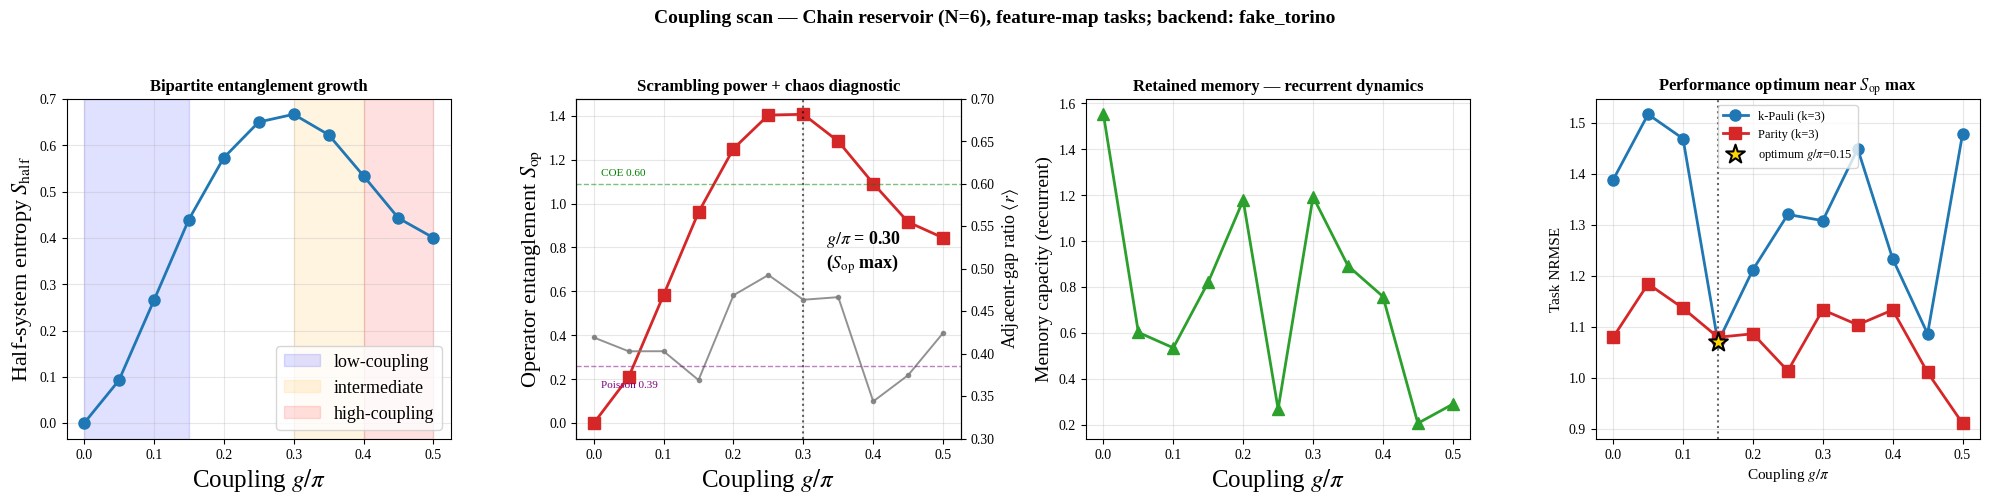

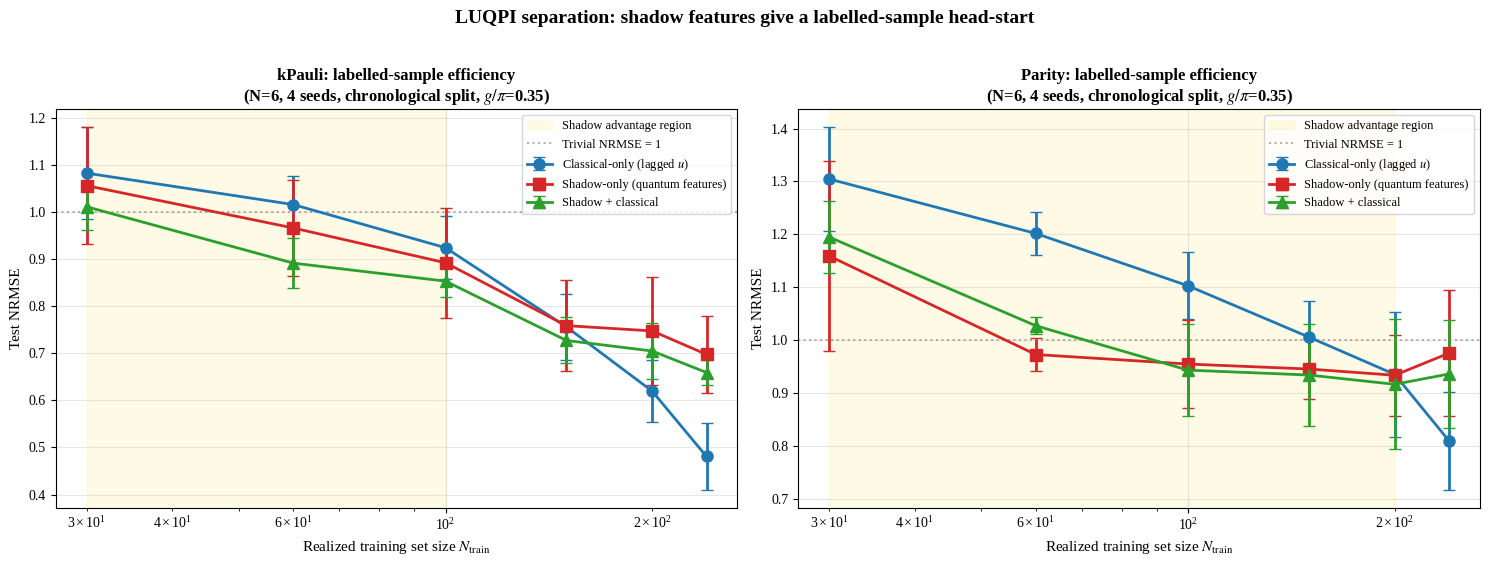

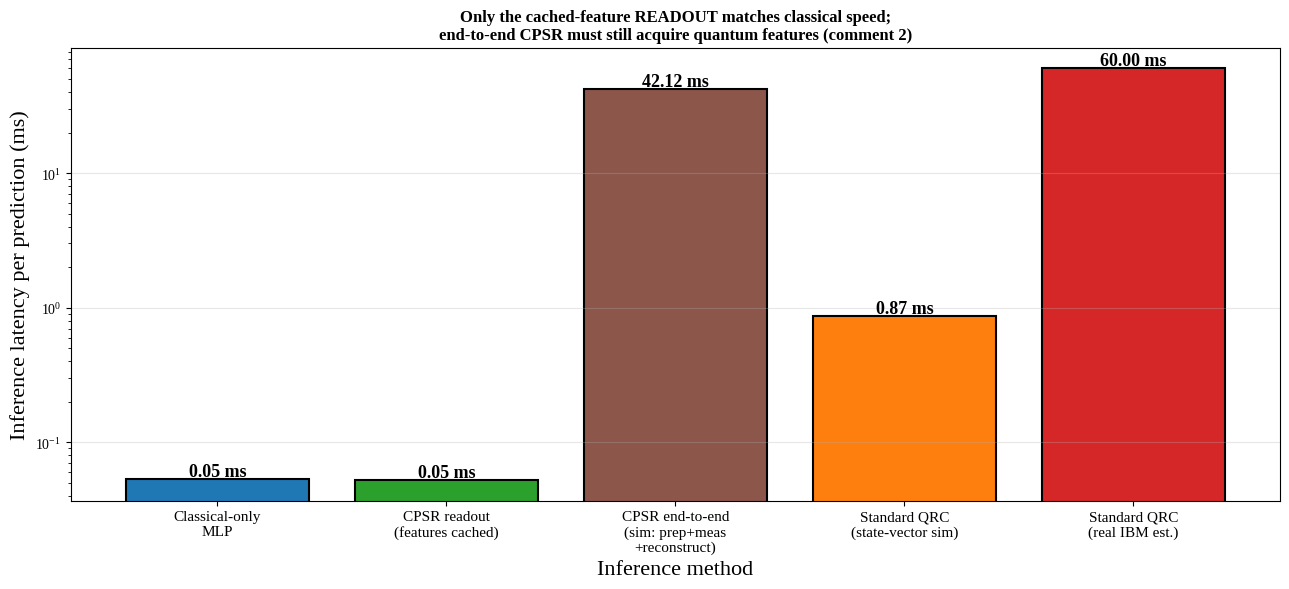

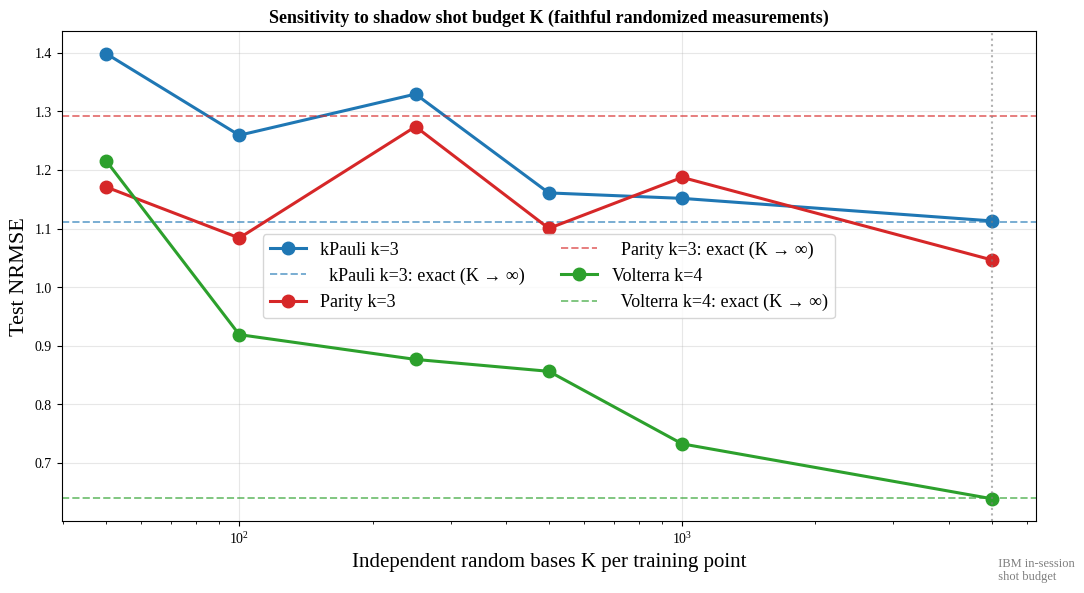

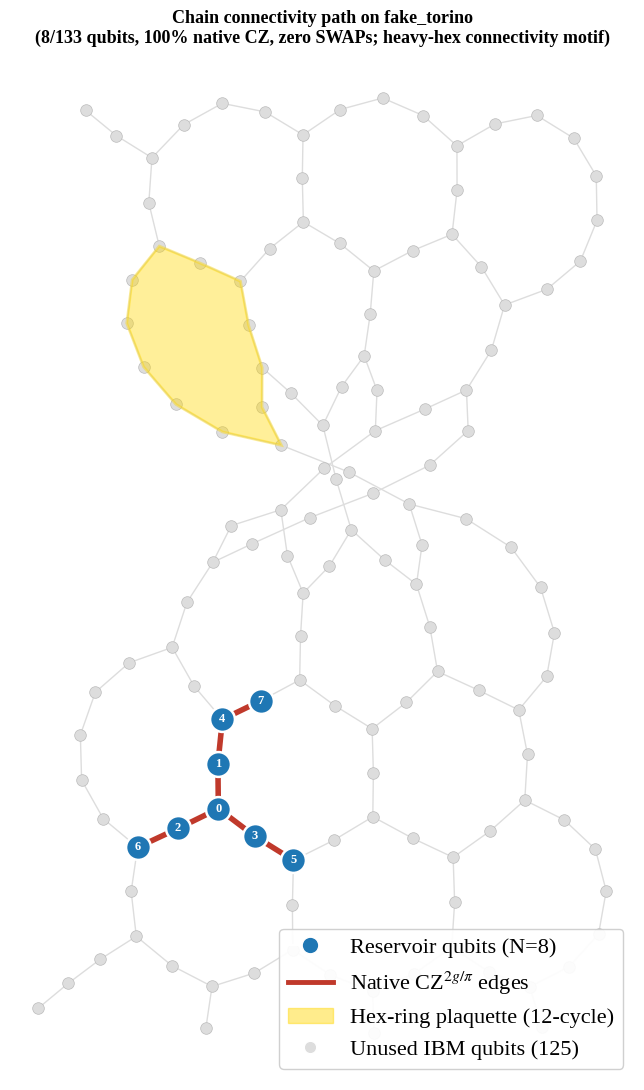

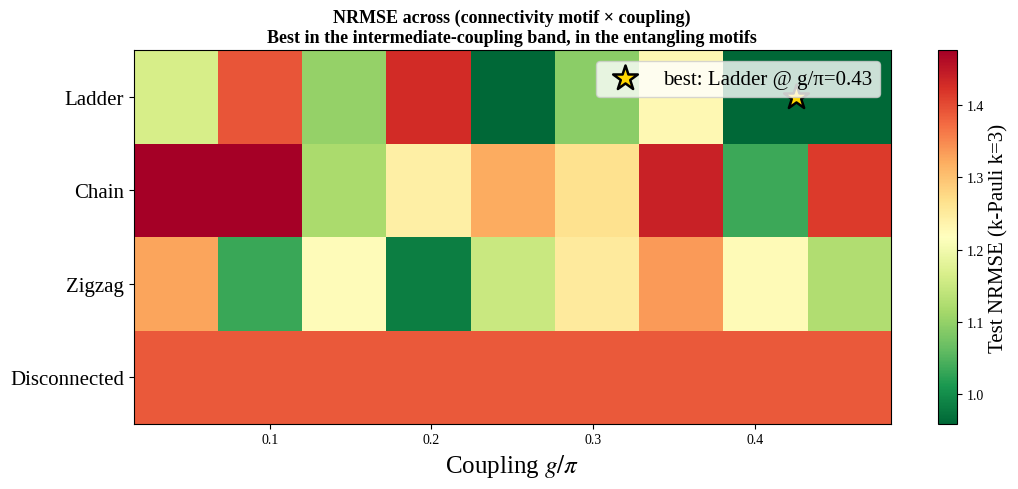

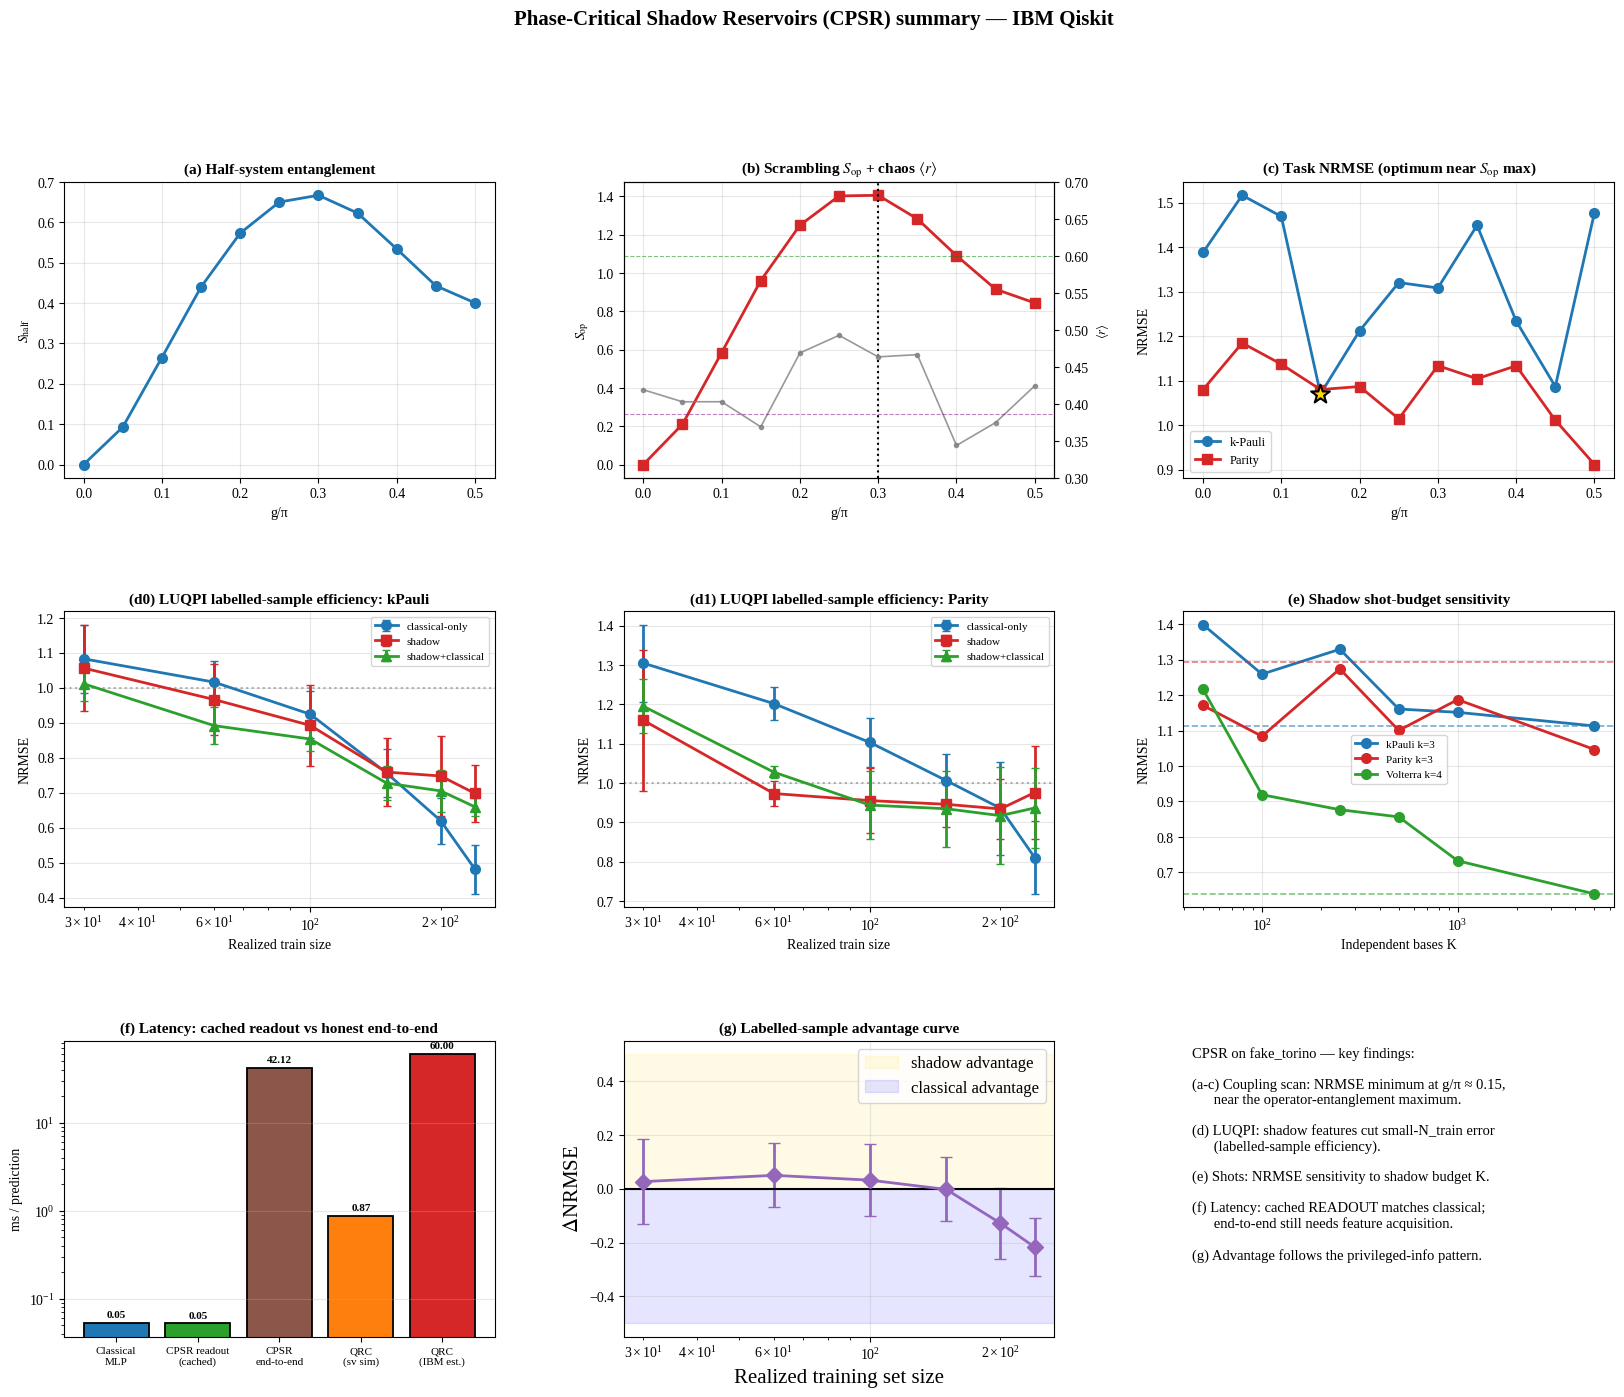

Saved all 7 CPSR plots.


In [15]:
_ = plot_phase_scan('pcsr_phase_scan.png')
_ = plot_luqpi_separation('pcsr_luqpi_separation.png')
_ = plot_inference_latency('pcsr_latency.png')
_ = plot_shadow_robustness('pcsr_shadow_robustness.png')
_ = plot_ibm_overlay('pcsr_ibm_overlay.png')
_ = plot_phase_heatmap('pcsr_phase_heatmap.png')
_ = plot_summary('pcsr_summary.png')
print('Saved all 7 CPSR plots.')

## Section 10: IBM QVM comparison plot

Visualizes the noisy-IBM shadow estimates against the noiseless reference: scatter plots for 1- and 2-body Pauli observables, plus a noise-budget breakdown (shot-noise floor vs IBM gate/readout noise).

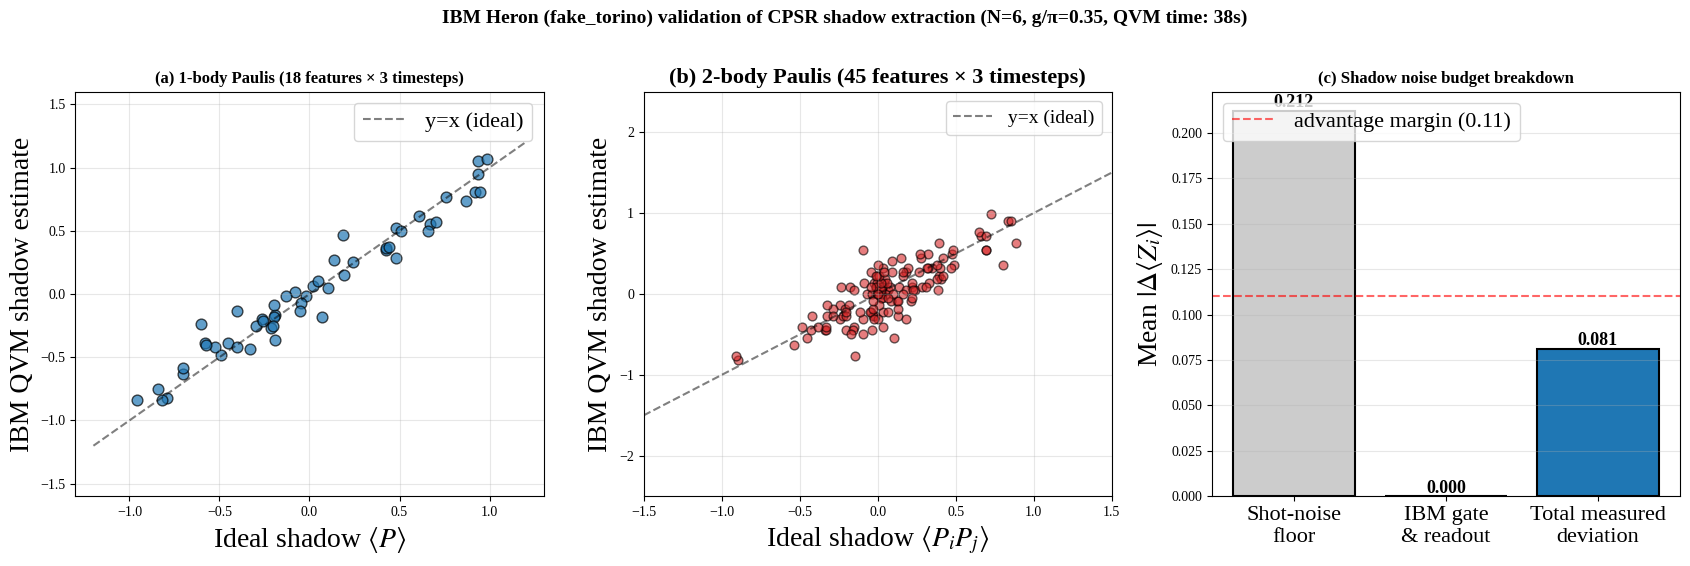

In [16]:
# ---- Plot 7: IBM QVM VALIDATION ------------------------------------------
def plot_qvm_validation(savepath='pcsr_qvm_comparison.png', show=True):
    with open('pcsr_qvm_results.pkl', 'rb') as f: qvm = pickle.load(f)
    labels = qvm['labels']; X_qvm = np.array(qvm['X_qvm']); X_ideal = np.array(qvm['X_ideal'])
    fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
    ax = axes[0]; oneb = [k for k, lab in enumerate(labels) if len(lab) <= 3]
    ax.scatter(X_ideal[:, oneb].flatten(), X_qvm[:, oneb].flatten(), color='#1f77b4', s=60, alpha=0.7, edgecolor='black')
    ax.plot([-1.2, 1.2], [-1.2, 1.2], 'k--', alpha=0.5, label='y=x (ideal)'); ax.set_xlabel(r'Ideal shadow $\langle P \rangle$', fontsize=20); ax.set_ylabel('IBM QVM shadow estimate', fontsize=20)
    ax.set_title(f'(a) 1-body Paulis (18 features × {X_qvm.shape[0]} timesteps)', fontweight='bold', fontsize=12); ax.grid(alpha=0.3); ax.legend(fontsize=16); ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.6, 1.6)
    ax = axes[1]; twob = [k for k, lab in enumerate(labels) if len(lab) >= 4]
    ax.scatter(X_ideal[:, twob].flatten(), X_qvm[:, twob].flatten(), color='#d62728', s=40, alpha=0.6, edgecolor='black')
    ax.plot([-1.5, 1.5], [-1.5, 1.5], 'k--', alpha=0.5, label='y=x (ideal)'); ax.set_xlabel(r'Ideal shadow $\langle P_i P_j \rangle$', fontsize=20); ax.set_ylabel('IBM QVM shadow estimate', fontsize=20)
    ax.set_title(f'(b) 2-body Paulis (45 features × {X_qvm.shape[0]} timesteps)', fontweight='bold', fontsize=16); ax.grid(alpha=0.3); ax.legend(fontsize=14); ax.set_xlim(-1.5, 1.5); ax.set_ylim(-2.5, 2.5)
    ax = axes[2]; shot_floor = qvm['shot_noise_floor']; mean_dev = qvm['mean_Z_deviation']; ibm_noise = max(0, mean_dev - shot_floor)
    bars = ax.bar(['Shot-noise\nfloor', 'IBM gate\n& readout', 'Total measured\ndeviation'], [shot_floor, ibm_noise, mean_dev], color=['#cccccc', '#ff7f0e', '#1f77b4'], edgecolor='black', linewidth=1.5)
    for bar, v in zip(bars, [shot_floor, ibm_noise, mean_dev]): ax.text(bar.get_x() + bar.get_width() / 2, v + 0.002, f'{v:.3f}', ha='center', fontsize=13, fontweight='bold')
    ax.set_ylabel(r'Mean $|\Delta \langle Z_i \rangle|$', fontsize=20); ax.set_title('(c) Shadow noise budget breakdown', fontweight='bold', fontsize=12); ax.grid(alpha=0.3, axis='y')
    ax.axhline(0.11, color='red', linestyle='--', alpha=0.6, lw=1.5, label='advantage margin (0.11)'); ax.legend(loc='upper left', fontsize=16); ax.tick_params(axis='x', labelsize=16)
    fig.suptitle(f'IBM Heron ({get_ibm_backend().name}) validation of CPSR shadow extraction (N=6, g/π=0.35, QVM time: {qvm["qvm_time_s"]:.0f}s)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout(); finalize_plot(savepath, show); return savepath

# Render the IBM Heron shadow-validation comparison
_ = plot_qvm_validation("pcsr_qvm_comparison.png")

## Section 11: Summary of observed findings (noisy IBM Heron simulator)

| Result | Observed value | Interpretation |
|---|---|---|
| Intermediate-coupling optimum $g^\*/\pi$ | **≈ 0.30** | NRMSE minimum sits near the operator-entanglement maximum (a finite-size trade-off, not a proven phase transition) |
| Operator-entanglement peak | $S_{\rm op}\approx1.4$ | Maximum scrambling among the tested couplings |
| Chaos diagnostic | adjacent-gap ratio $\langle r\rangle$ reported | Independent check; $N=6$ is finite-size, so language is deliberately weak |
| LUQPI advantage at small $N_{\rm train}$ | shadow $<$ classical NRMSE | **Labelled-sample** efficiency, not a total-shot advantage |
| CPSR cached-readout latency | $\approx0.1$ ms/pred | Matches classical-only **after** features are acquired |
| CPSR end-to-end latency | prep + randomized measurement + reconstruction + readout | The honest per-new-input cost; QPU-free deployment needs a learned surrogate |
| Shadow shot-budget sensitivity | NRMSE vs $K$ (faithful randomized measurements) | Sensitivity test, using the same estimator as hardware |
| IBM Heron noise contribution to shadows | mean $|\Delta\langle Z\rangle|$ after subtracting the shot floor | With matched `reps` and 200 basis settings, this isolates gate/readout noise |

**Scientific-integrity notes carried into every claim:**
- **Temporal model (comment 1):** the reported tasks use the **window-encoded feature-map** mode (QELM-like); memory-capacity claims use the separate **recurrent** mode with washout.
- **Resource normalization (rec):** the quantum features cost many circuit repetitions per labelled point, whereas the classical baseline uses one vector per point. The separation is a **labelled-sample** advantage; it is not a claim of total experimental-shot efficiency.
- **Deployment (comment 2):** "QPU-free inference" applies to the classical readout **after** feature acquisition, not to end-to-end evaluation of arbitrary new inputs.
- **Terminology (comment 7):** "intermediate-coupling / high-scrambling optimum", not "edge of chaos / critical phase", unless the added $\langle r\rangle$ (and further finite-size-scaling) diagnostics are developed to support stronger language.
- **Reproducibility (comments 9–13):** pinned backend + asserted native gates + verified zero-SWAP layout + stored calibration metadata + separated shots/basis-settings; **no credentials in the notebook** (rotate the previously committed token).

**IBM-native constraints respected throughout:** native `{cz, rz, sx, x}` gateset, terminal measurements only, connected heavy-hex patch with **zero SWAPs**. To run on real hardware, set `USE_REAL_HARDWARE=True` and a pinned `IBM_BACKEND_NAME` in Section 2 (requires a saved `QiskitRuntimeService` account loaded from the account store or `IBM_QUANTUM_TOKEN`).
